In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import time
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier, RandomForestRegressor)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, precision_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix


import warnings
warnings.filterwarnings("ignore")

# metrics
from imblearn.metrics import sensitivity_score, geometric_mean_score

#resampling methods
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# pipeline
from imblearn.pipeline import Pipeline

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# data_dir = '/content/drive/MyDrive/Colab Notebooks/ML2 project/'

In [2]:
"""
https://pmc.ncbi.nlm.nih.gov/articles/PMC9687310/#sec2-biomedicines-10-02697
Haematocrit (HCT): Male normal range is 40.0–52.0%, while Female normal range is	37.0–47.0%
HAEMOGLOBINS (Hb): Male normal range is	13.0–17.0 g/dL while female normal range is	12.0–16.0 g/dL
ERYTHROCYTE (RBC): Male normal range is	4.5–6.1 × 106/μL, while female normal range is	4.0–5.4 × 106/μL
LEUCOCYTE (WBC): Male and female normal range is	4.0–10.8 × 103/μL
THROMBOCYTE (PLT): Male and female normal range is	150–400 × 103/μL
MCH: Male and female normal range is 27.0–33.0 pg
MCHC: Male and female normal range is	31.5–37.0 g/dL
MCV: Male and female normal range	80–98 fL	80–98 fL
"""

# df = pd.read_csv(data_dir +'data-ori.csv')
# df.head()

#Cams
df_raw = pd.read_csv('data-ori.csv')
df_raw.head()



,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,35.1,11.8,4.65,6.3,310,25.4,33.6,75.5,1,F,out
1,43.5,14.8,5.39,12.7,334,27.5,34.0,80.7,1,F,out
2,33.5,11.3,4.74,13.2,305,23.8,33.7,70.7,1,F,out
3,39.1,13.7,4.98,10.5,366,27.5,35.0,78.5,1,F,out
4,30.9,9.9,4.23,22.1,333,23.4,32.0,73.0,1,M,out


In [4]:
# # Create age group column
# df_raw['AGE'] = pd.cut(df_raw['AGE'], bins=[0, 18, 70, float('inf')], labels=['Under 18', 'Others', 'Over 70'], right=False)

# # Group by age_group and gender, and count occurrences
# result = df_raw.groupby(['AGE', 'SEX']).size().reset_index(name='count')

# # Display the result
# print(result)

Split Male and Female

In [3]:
df = df_raw
df_male = df_raw[df_raw['SEX'] == "M"]
df_female = df_raw[df_raw['SEX'] == "F"]
# df = df[df['AGE'] >= 18]
# df = df[df['AGE'] <= 70]

# EDA

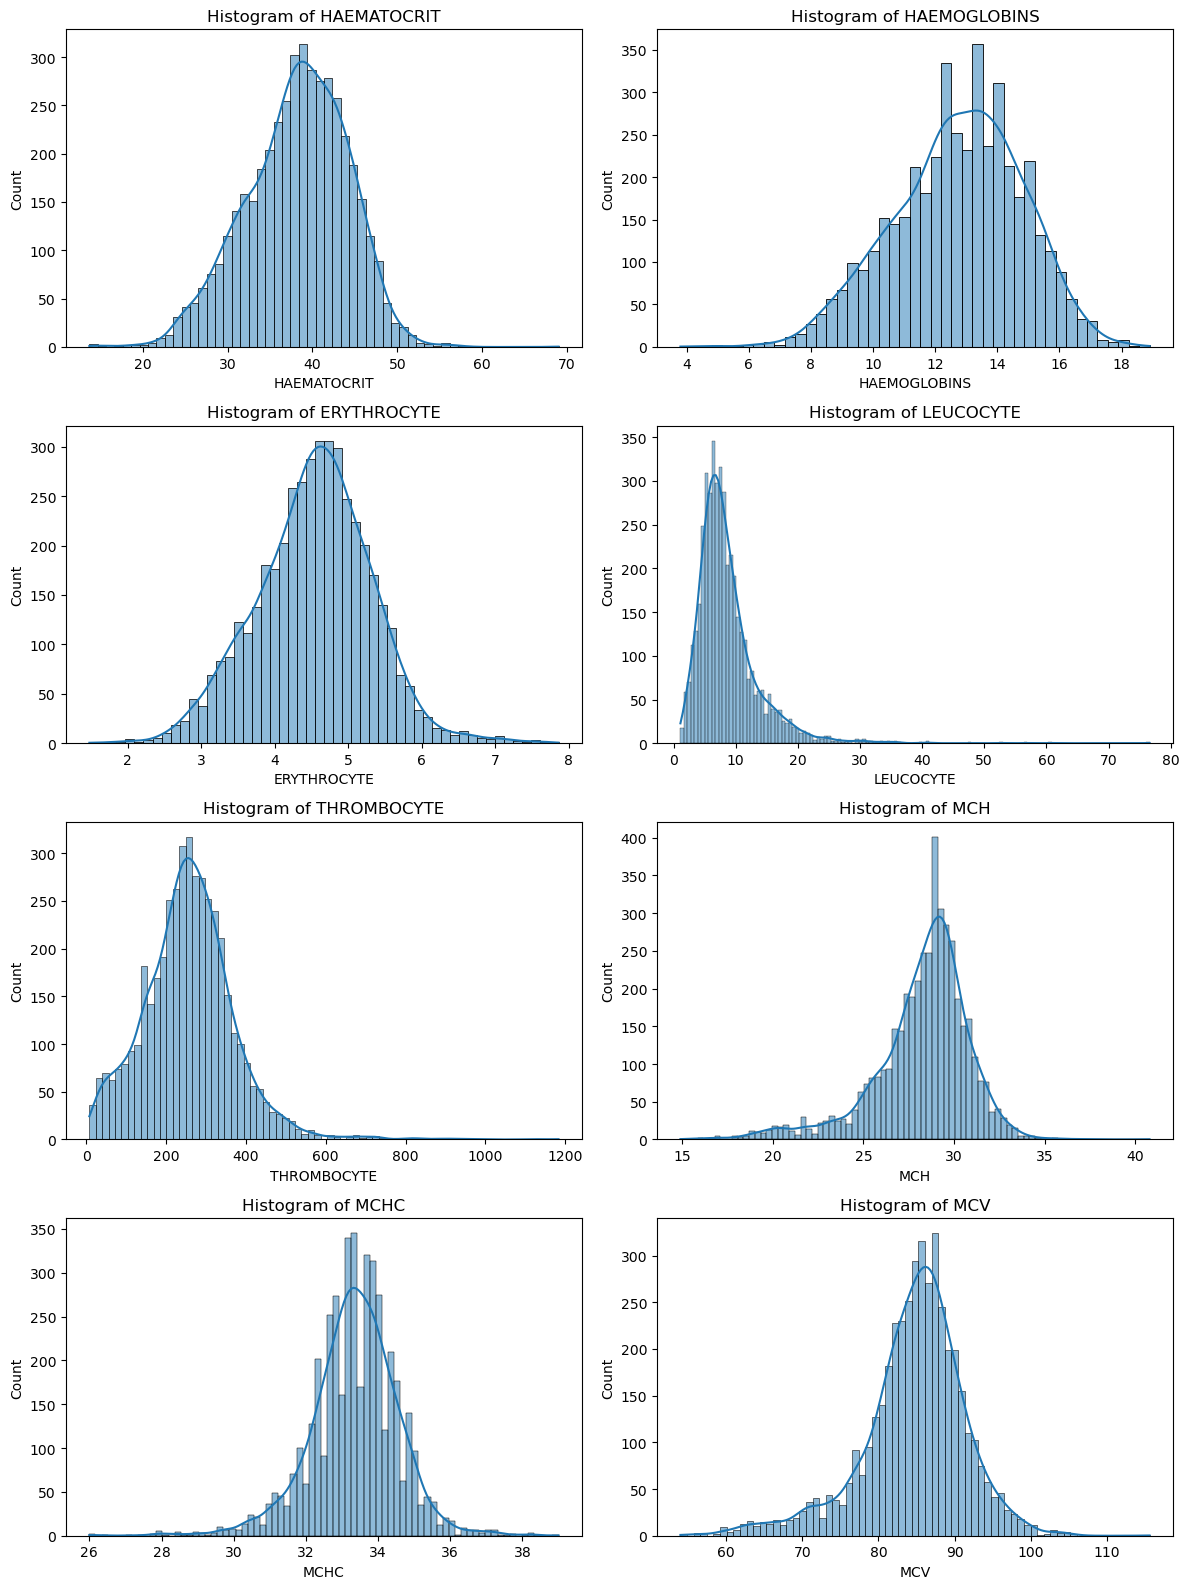

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()


for i, col in enumerate(df_raw.columns[:8]):
    sns.histplot(df_raw[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')


plt.tight_layout()
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4412 entries, 0 to 4411
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HAEMATOCRIT   4412 non-null   float64
 1   HAEMOGLOBINS  4412 non-null   float64
 2   ERYTHROCYTE   4412 non-null   float64
 3   LEUCOCYTE     4412 non-null   float64
 4   THROMBOCYTE   4412 non-null   int64  
 5   MCH           4412 non-null   float64
 6   MCHC          4412 non-null   float64
 7   MCV           4412 non-null   float64
 8   AGE           4412 non-null   int64  
 9   SEX           4412 non-null   object 
 10  SOURCE        4412 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 379.3+ KB


In [6]:
df.notna().count()

HAEMATOCRIT     4412
HAEMOGLOBINS    4412
ERYTHROCYTE     4412
LEUCOCYTE       4412
THROMBOCYTE     4412
MCH             4412
MCHC            4412
MCV             4412
AGE             4412
SEX             4412
SOURCE          4412
dtype: int64

In [7]:
df['SEX'].unique()
df['SEX'] = df['SEX'].apply(lambda x: 1 if x == 'F' else 0)
df_male['SEX'] = df_male['SEX'].apply(lambda x: 1 if x == 'F' else 0)
df_female['SEX'] = df_female['SEX'].apply(lambda x: 1 if x == 'F' else 0)

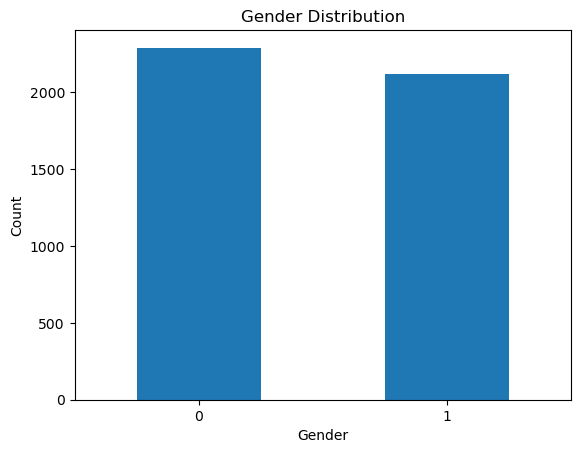

In [8]:
gender_counts = df['SEX'].value_counts()

gender_counts.plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [9]:
# Overall (df)
df_total_count = len(df)
df_in_count = (df['SOURCE'] == 'in').sum()
df_out_count = (df['SOURCE'] == 'out').sum()
df_in_normalized = (df_in_count / df_total_count) * 100
df_out_normalized = (df_out_count / df_total_count) * 100

# Male (df_male)
df_male_total_count = len(df_male)
df_male_in_count = (df_male['SOURCE'] == 'in').sum()
df_male_out_count = (df_male['SOURCE'] == 'out').sum()
df_male_in_normalized = (df_male_in_count / df_male_total_count) * 100
df_male_out_normalized = (df_male_out_count / df_male_total_count) * 100

# Female (df_female)
df_female_total_count = len(df_female)
df_female_in_count = (df_female['SOURCE'] == 'in').sum()
df_female_out_count = (df_female['SOURCE'] == 'out').sum()
df_female_in_normalized = (df_female_in_count / df_female_total_count) * 100
df_female_out_normalized = (df_female_out_count / df_female_total_count) * 100

# Create a DataFrame manually
summary_df = pd.DataFrame({
    'Total Count': [df_total_count, df_male_total_count, df_female_total_count],
    'In Count': [df_in_count, df_male_in_count, df_female_in_count],
    'Out Count': [df_out_count, df_male_out_count, df_female_out_count],
    'In Normalized (%)': [df_in_normalized, df_male_in_normalized, df_female_in_normalized],
    'Out Normalized (%)': [df_out_normalized, df_male_out_normalized, df_female_out_normalized]
}, index=['Overall', 'Male', 'Female'])

# Display the summary DataFrame
summary_df


,Total Count,In Count,Out Count,In Normalized (%),Out Normalized (%)
Overall,4412,1784,2628,40.435177,59.564823
Male,2290,982,1308,42.882096,57.117904
Female,2122,802,1320,37.794533,62.205467


In [10]:
df['SOURCE'] = df['SOURCE'].apply(lambda x: 1 if x=='in' else 0)
df_male['SOURCE'] = df_male['SOURCE'].apply(lambda x: 1 if x=='in' else 0)
df_female['SOURCE'] = df_female['SOURCE'].apply(lambda x: 1 if x=='in' else 0)


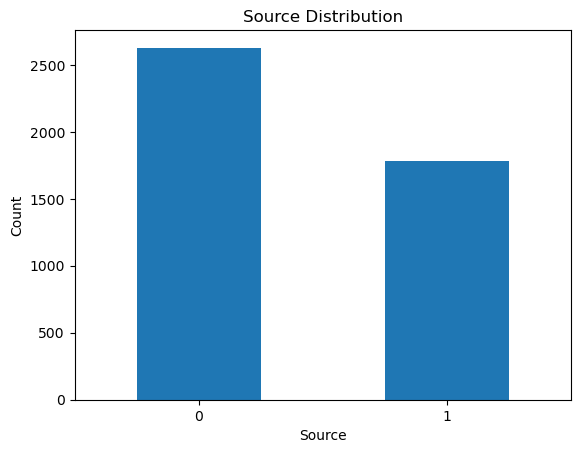

In [11]:
source_counts = df['SOURCE'].value_counts()

source_counts.plot(kind='bar')
plt.title('Source Distribution')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [12]:
df.columns

Index(['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
       'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX', 'SOURCE'],
      dtype='object')

In [15]:
# columns_to_scale = ['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE'
#                     , 'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE']

# scaler = MinMaxScaler()
# df[columns_to_scale] = scaler.fit(df[columns_to_scale])


# Training

## All

In [13]:
X, y = df.drop(['SOURCE'], axis=1), df['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)

In [14]:
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
2586,31.9,11.0,3.78,7.7,211,29.1,34.5,84.4,54,0
3287,38.4,13.2,3.98,6.5,241,33.2,34.4,96.5,64,0
3393,27.3,9.0,3.23,26.8,678,27.9,33.0,84.5,65,1
3700,44.9,14.9,5.26,4.2,14,28.3,33.2,85.4,69,0
326,39.7,13.9,5.63,21.6,356,24.7,35.0,70.5,14,0
...,...,...,...,...,...,...,...,...,...,...
36,38.4,12.7,4.68,3.4,136,27.1,33.1,82.1,2,0
1567,45.3,15.7,5.31,6.5,246,29.6,34.7,85.3,37,0
1047,41.1,13.6,5.01,2.8,131,27.1,33.1,82.0,29,1
3664,38.5,12.8,5.07,16.2,284,25.2,33.2,75.9,69,1


In [15]:
models_dict = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegressor': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(random_state=6),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=6),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=6),
    'XGBClassifier': XGBClassifier(random_state=6)
}

In [16]:
skf = StratifiedKFold(n_splits=5)

res = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []


    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             (model_name, model)])
        # fit
        pipeline.fit(X_train, y_train)

        #predict
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    res[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
res = pd.DataFrame(res).T
display(res)

100%|██████████| 6/6 [00:09<00:00,  1.66s/it]

Report Generated in 9.95 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,61.433022,70.410281,72.997481,76.299685,67.184637,80.845666,142.278688,0.084430
LogisticRegressor,47.538941,64.460976,71.309824,75.684733,67.524993,87.441860,134.980801,0.273667
RandomForestClassifier,61.308411,71.930258,75.088161,79.871240,75.674608,84.439746,145.748158,0.826163
DecisionTreeClassifier,60.186916,66.047261,67.581864,66.393669,52.222309,72.600423,132.787339,0.039076
GradientBoostingClassifier,59.750779,71.563743,75.264484,80.425665,75.754946,85.792812,145.543591,0.661745
XGBClassifier,63.551402,72.516740,75.012594,79.393412,75.280447,82.790698,146.342100,0.121351


### RUS

In [18]:
skf = StratifiedKFold(n_splits=5)

undersampler = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomUnderSampler',
                              RandomUnderSampler(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    undersampler[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
undersampler = pd.DataFrame(undersampler).T
display(undersampler)

100%|██████████| 6/6 [00:09<00:00,  1.63s/it]

Report Generated in 9.79 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,67.850467,69.978996,70.503778,75.364249,65.124924,72.304440,140.154907,0.270519
LogisticRegressor,66.666667,69.997142,70.755668,75.578168,67.228953,73.530655,140.197322,0.100898
RandomForestClassifier,68.722741,72.645739,73.576826,79.289483,75.278485,76.871036,145.593777,0.732764
DecisionTreeClassifier,65.046729,65.014172,65.012594,65.018079,50.456061,64.989429,130.036158,0.040204
GradientBoostingClassifier,68.660436,73.229672,74.332494,80.106433,75.484653,78.181818,146.842254,0.589915
XGBClassifier,68.660436,71.290697,71.914358,78.362807,73.778368,74.122622,142.783058,0.185684


### ROS

In [19]:
skf = StratifiedKFold(n_splits=5)

oversampler = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomOverSampler',
                              RandomOverSampler(random_state=143)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    oversampler[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
oversampler = pd.DataFrame(oversampler).T
display(oversampler)

100%|██████████| 6/6 [00:12<00:00,  2.04s/it]

Report Generated in 12.26 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,68.909657,70.122836,70.403023,75.503151,65.944836,71.416490,140.326148,0.302265
LogisticRegressor,66.604361,69.886271,70.629723,75.680386,67.469092,73.361522,139.965884,0.199392
RandomForestClassifier,64.236760,72.828328,75.188917,79.789440,75.962260,82.621564,146.858325,0.909438
DecisionTreeClassifier,60.685358,65.729109,67.027708,66.008641,51.738533,71.331924,132.017282,0.048168
GradientBoostingClassifier,68.161994,73.118838,74.307305,80.135083,75.706274,78.477801,146.639795,0.783893
XGBClassifier,63.862928,71.503369,73.576826,78.774443,74.611138,80.169133,144.032062,0.134923


### SMOTE

In [20]:
skf = StratifiedKFold(n_splits=5)

smote = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('SMOTEr',
                              SMOTE(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    smote[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
smote = pd.DataFrame(smote).T
display(smote)

100%|██████████| 6/6 [00:14<00:00,  2.36s/it]

Report Generated in 14.16 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,68.473520,69.985239,70.352645,75.899508,66.237069,71.627907,140.101427,0.306077
LogisticRegressor,65.981308,69.741419,70.604534,75.651802,67.386306,73.742072,139.723380,0.201323
RandomForestClassifier,66.292835,73.043528,74.760705,79.715938,75.768014,80.507400,146.800234,1.063814
DecisionTreeClassifier,61.370717,66.149095,67.304786,66.351320,52.029299,71.331924,132.702640,0.068443
GradientBoostingClassifier,68.411215,73.328671,74.508816,80.177366,75.724273,78.646934,147.058149,0.955052
XGBClassifier,66.853583,72.043744,73.324937,78.956222,74.338729,77.716702,144.570284,0.179034


### ADASYN

In [21]:
skf = StratifiedKFold(n_splits=5)

adasyn= {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('ADASYN',
                              ADASYN(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    adasyn[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
adasyn = pd.DataFrame(adasyn).T
display(adasyn)

100%|██████████| 6/6 [00:14<00:00,  2.48s/it]

Report Generated in 14.88 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,70.965732,68.695217,68.362720,74.416234,63.533038,66.596195,137.561927,0.328475
LogisticRegressor,66.230530,69.641904,70.428212,75.645874,67.419597,73.276956,139.507485,0.293318
RandomForestClassifier,66.915888,72.808384,74.282116,79.710274,75.687220,79.281184,146.197072,1.058567
DecisionTreeClassifier,63.551402,65.251422,65.667506,65.327498,50.810219,67.103594,130.654996,0.091475
GradientBoostingClassifier,67.663551,72.569971,73.753149,79.264192,75.184108,77.885835,145.549386,0.933073
XGBClassifier,67.040498,71.998020,73.224181,78.225946,73.839173,77.420719,144.461217,0.197653


### Recall Result

In [22]:
combined_res = pd.DataFrame(index=models_dict.keys())
combined_res['NoResampling Val Recall'] = res['ave_val_recall']
combined_res['RandomUndersampling Val Recall'] = undersampler['ave_val_recall']
combined_res['RandomOversampling Val Recall'] = oversampler['ave_val_recall']
combined_res['SMOTE Val Recall'] = smote['ave_val_recall']
combined_res['ADASYN Val Recall'] = adasyn['ave_val_recall']
combined_res

,NoResampling Val Recall,RandomUndersampling Val Recall,RandomOversampling Val Recall,SMOTE Val Recall,ADASYN Val Recall
KNeighborsClassifier,61.433022,67.850467,68.909657,68.473520,70.965732
LogisticRegressor,47.538941,66.666667,66.604361,65.981308,66.230530
RandomForestClassifier,61.308411,68.722741,64.236760,66.292835,66.915888
DecisionTreeClassifier,60.186916,65.046729,60.685358,61.370717,63.551402
GradientBoostingClassifier,59.750779,68.660436,68.161994,68.411215,67.663551
XGBClassifier,63.551402,68.660436,63.862928,66.853583,67.040498


### Spec + Sens

In [23]:
combined_spec_sens = pd.DataFrame(index=models_dict.keys())
combined_spec_sens['NoResampling Val Specificity + Sensitivity'] = res['Specificity + Sensitivity']
combined_spec_sens['RandomUndersampling Val Specificity + Sensitivity'] = undersampler['Specificity + Sensitivity']
combined_spec_sens['RandomOversampling Val Specificity + Sensitivity'] = oversampler['Specificity + Sensitivity']
combined_spec_sens['SMOTE Val Specificity + Sensitivity'] = smote['Specificity + Sensitivity']
combined_spec_sens

,NoResampling Val Specificity + Sensitivity,RandomUndersampling Val Specificity + Sensitivity,RandomOversampling Val Specificity + Sensitivity,SMOTE Val Specificity + Sensitivity
KNeighborsClassifier,142.278688,140.154907,140.326148,140.101427
LogisticRegressor,134.980801,140.197322,139.965884,139.723380
RandomForestClassifier,145.748158,145.593777,146.858325,146.800234
DecisionTreeClassifier,132.787339,130.036158,132.017282,132.702640
GradientBoostingClassifier,145.543591,146.842254,146.639795,147.058149
XGBClassifier,146.342100,142.783058,144.032062,144.570284


## Male

In [24]:
X, y = df_male.drop(['SOURCE', 'SEX'], axis=1), df_male['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
3673,44.0,14.8,5.03,9.2,333,29.4,33.6,87.5,69
415,35.1,11.9,3.91,6.6,277,30.4,33.9,89.8,17
1190,46.0,15.9,5.26,6.8,317,30.2,34.6,87.5,30
3499,39.7,13.5,4.72,4.6,186,28.6,34.0,84.1,67
4143,31.2,11.1,3.03,10.8,179,36.6,35.6,103.0,78
...,...,...,...,...,...,...,...,...,...
130,38.8,13.5,5.17,4.8,270,26.1,34.8,75.0,5
1581,49.6,16.8,5.86,10.5,310,28.7,33.9,84.6,37
2503,28.8,9.8,3.41,15.7,181,28.7,34.0,84.5,53
2032,37.9,13.1,4.40,4.7,84,29.8,34.6,86.1,45


### Initial Run

In [25]:
skf = StratifiedKFold(n_splits=5)

res_male = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []


    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             (model_name, model)])
        # fit
        pipeline.fit(X_train, y_train)

        #predict
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    res_male[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
res_male = pd.DataFrame(res_male).T
display(res_male)

100%|██████████| 6/6 [00:06<00:00,  1.01s/it]

Report Generated in 6.08 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,65.607987,72.396858,73.797339,78.965895,72.569236,79.945546,145.553533,0.053999
LogisticRegressor,53.613893,67.704255,71.856884,77.164792,72.193412,85.554995,139.168888,0.098835
RandomForestClassifier,67.419748,75.079298,76.709137,82.364807,80.415808,83.682294,151.102042,0.486964
DecisionTreeClassifier,65.047509,68.971782,69.721550,69.140595,57.115369,73.233682,138.281191,0.025928
GradientBoostingClassifier,64.931305,73.705915,75.690308,81.686225,79.716430,83.769203,148.700508,0.410428
XGBClassifier,67.644453,73.999526,75.301606,80.913914,78.703565,81.048684,148.693137,0.111297


### RUS

In [26]:
skf = StratifiedKFold(n_splits=5)

undersampler_male = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomUnderSampler',
                              RandomUnderSampler(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    undersampler_male[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
undersampler_male = pd.DataFrame(undersampler_male).T
display(undersampler_male)

100%|██████████| 6/6 [00:06<00:00,  1.06s/it]

Report Generated in 6.36 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,70.359527,71.879122,72.148029,78.437822,71.431320,73.490804,143.850332,0.134201
LogisticRegressor,65.833975,70.240777,71.079950,77.039744,71.902996,75.018752,140.852728,0.114696
RandomForestClassifier,71.266692,74.611965,75.205811,82.192738,80.134372,78.162640,149.429332,0.435424
DecisionTreeClassifier,68.438624,67.538560,67.488540,67.605175,55.293151,66.771727,135.210351,0.025807
GradientBoostingClassifier,70.923215,74.730801,75.447119,81.990096,79.732279,78.838442,149.761657,0.381369
XGBClassifier,71.603107,73.771386,74.185924,81.351959,78.523983,76.118644,147.721751,0.113801


### ROS

In [27]:
skf = StratifiedKFold(n_splits=5)

oversampler_male = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomOverSampler',
                              RandomOverSampler(random_state=143)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    oversampler_male[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
oversampler_male = pd.DataFrame(oversampler_male).T
display(oversampler_male)

100%|██████████| 6/6 [00:07<00:00,  1.21s/it]

Report Generated in 7.26 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,70.358243,71.833413,72.098780,78.368956,71.292913,73.403173,143.761417,0.142910
LogisticRegressor,66.511299,70.572672,71.322669,77.195714,72.266171,74.932925,141.444224,0.108145
RandomForestClassifier,69.341936,75.245720,76.417405,82.269276,80.556465,81.728453,151.070389,0.524894
DecisionTreeClassifier,65.719697,68.360572,68.848233,68.455773,56.301774,71.191850,136.911547,0.028648
GradientBoostingClassifier,69.791346,74.367775,75.252709,81.460151,79.362063,79.347277,149.138623,0.449530
XGBClassifier,68.889317,73.533688,74.477186,81.091496,78.695124,78.666426,147.555743,0.116403


### SMOTE

In [28]:
skf = StratifiedKFold(n_splits=5)

smote_male = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('SMOTEr',
                              SMOTE(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    smote_male[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
smote_male = pd.DataFrame(smote_male).T
display(smote_male)

100%|██████████| 6/6 [00:08<00:00,  1.38s/it]

Report Generated in 8.31 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,70.471238,71.436070,71.613813,78.231144,71.377669,72.468806,142.940044,0.142792
LogisticRegressor,66.510657,70.950298,71.807753,77.195105,72.140824,75.783267,142.293925,0.196778
RandomForestClassifier,69.906908,75.367125,76.418110,82.055242,80.187558,81.305085,151.211993,0.584220
DecisionTreeClassifier,63.572162,67.190677,67.829874,67.299604,55.235416,71.027047,134.599209,0.042047
GradientBoostingClassifier,69.905624,74.568939,75.447002,81.735764,80.065458,79.605481,149.511105,0.559988
XGBClassifier,69.680919,73.781360,74.573803,81.155000,78.449415,78.243419,147.924338,0.127281


### ADASYN

In [29]:
skf = StratifiedKFold(n_splits=5)

adasyn_male= {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('ADASYN',
                              ADASYN(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    adasyn_male[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
adasyn_male = pd.DataFrame(adasyn_male).T
display(adasyn_male)

100%|██████████| 6/6 [00:08<00:00,  1.45s/it]

Report Generated in 8.70 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,74.091551,69.583731,69.140318,77.082689,69.700916,65.419041,139.510592,0.161701
LogisticRegressor,69.564715,70.893451,71.128729,77.163794,72.219645,72.298954,141.863669,0.196737
RandomForestClassifier,70.924499,74.395629,75.059357,81.832617,80.110388,78.158673,149.083172,0.707752
DecisionTreeClassifier,67.760657,67.902786,67.925903,67.905933,55.546718,68.051208,135.811865,0.051188
GradientBoostingClassifier,72.393426,73.302677,73.554033,81.208305,79.723419,74.416516,146.809942,0.539176
XGBClassifier,71.490113,73.329685,73.700604,80.829693,78.227866,75.354850,146.844963,0.159873


### Recall Result Male

In [30]:
combined_res_male = pd.DataFrame(index=models_dict.keys())
combined_res_male['NoResampling Val Recall'] = res_male['ave_val_recall']
combined_res_male['RandomUndersampling Val Recall'] = undersampler_male['ave_val_recall']
combined_res_male['RandomOversampling Val Recall'] = oversampler_male['ave_val_recall']
combined_res_male['SMOTE Val Recall'] = smote_male['ave_val_recall']
combined_res_male['ADASYN Val Recall'] = adasyn_male['ave_val_recall']
combined_res_male

,NoResampling Val Recall,RandomUndersampling Val Recall,RandomOversampling Val Recall,SMOTE Val Recall,ADASYN Val Recall
KNeighborsClassifier,65.607987,70.359527,70.358243,70.471238,74.091551
LogisticRegressor,53.613893,65.833975,66.511299,66.510657,69.564715
RandomForestClassifier,67.419748,71.266692,69.341936,69.906908,70.924499
DecisionTreeClassifier,65.047509,68.438624,65.719697,63.572162,67.760657
GradientBoostingClassifier,64.931305,70.923215,69.791346,69.905624,72.393426
XGBClassifier,67.644453,71.603107,68.889317,69.680919,71.490113


Spec + Sens Male

In [31]:
combined_spec_sens_male = pd.DataFrame(index=models_dict.keys())
combined_spec_sens_male['NoResampling Val Specificity + Sensitivity'] = res_male['Specificity + Sensitivity']
combined_spec_sens_male['RandomUndersampling Val Specificity + Sensitivity'] = undersampler_male['Specificity + Sensitivity']
combined_spec_sens_male['RandomOversampling Val Specificity + Sensitivity'] = oversampler_male['Specificity + Sensitivity']
combined_spec_sens_male['SMOTE Val Specificity + Sensitivity'] = smote_male['Specificity + Sensitivity']
combined_spec_sens_male['ADASYN Val Specificity + Sensitivity'] = adasyn_male['Specificity + Sensitivity']
combined_spec_sens_male

,NoResampling Val Specificity + Sensitivity,RandomUndersampling Val Specificity + Sensitivity,RandomOversampling Val Specificity + Sensitivity,SMOTE Val Specificity + Sensitivity,ADASYN Val Specificity + Sensitivity
KNeighborsClassifier,145.553533,143.850332,143.761417,142.940044,139.510592
LogisticRegressor,139.168888,140.852728,141.444224,142.293925,141.863669
RandomForestClassifier,151.102042,149.429332,151.070389,151.211993,149.083172
DecisionTreeClassifier,138.281191,135.210351,136.911547,134.599209,135.811865
GradientBoostingClassifier,148.700508,149.761657,149.138623,149.511105,146.809942
XGBClassifier,148.693137,147.721751,147.555743,147.924338,146.844963


## Female

In [32]:
X, y = df_female.drop(['SOURCE', 'SEX'], axis=1), df_female['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
2960,39.8,13.2,4.40,8.5,362,30.0,33.2,90.5,59
273,36.8,12.7,4.83,9.7,286,26.3,34.5,76.2,11
1111,39.2,13.5,4.62,3.0,150,29.2,34.4,84.8,30
4002,33.1,10.7,3.74,8.0,450,28.6,32.3,88.5,75
965,31.0,10.0,3.83,9.7,202,26.1,32.3,80.9,27
...,...,...,...,...,...,...,...,...,...
3378,32.4,10.7,3.87,18.2,466,27.6,33.0,83.7,65
3468,34.4,11.4,3.57,4.2,222,31.9,33.1,96.4,66
1242,35.3,12.2,4.15,9.6,273,29.4,34.6,85.1,32
1106,32.8,10.7,3.69,7.5,315,29.0,32.6,88.9,29


### Initial Run

In [33]:
skf = StratifiedKFold(n_splits=5)

res_female = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []


    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             (model_name, model)])
        # fit
        pipeline.fit(X_train, y_train)

        #predict
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    res_female[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
res_female = pd.DataFrame(res_female).T
display(res_female)

100%|██████████| 6/6 [00:05<00:00,  1.03it/s]

Report Generated in 5.84 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,55.771073,66.967051,71.348202,73.015749,62.218300,80.810552,136.581625,0.040169
LogisticRegressor,36.209770,57.282040,70.404969,73.101209,61.042465,91.163351,127.373122,0.100468
RandomForestClassifier,54.240421,68.416870,74.333869,77.136634,70.817131,86.531929,140.772351,0.472835
DecisionTreeClassifier,56.453065,63.762627,66.211953,64.296631,47.616106,72.140198,128.593263,0.025128
GradientBoostingClassifier,51.468391,66.554927,73.233843,76.326993,68.611916,86.448605,137.916996,0.389637
XGBClassifier,55.907088,68.556417,73.653241,75.548407,68.547181,84.429671,140.336759,0.113099


### RUS

In [34]:
skf = StratifiedKFold(n_splits=5)

undersampler_female = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomUnderSampler',
                              RandomUnderSampler(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)


    undersampler_female[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed_female = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
undersampler_female = pd.DataFrame(undersampler_female).T
display(undersampler_female)

100%|██████████| 6/6 [00:05<00:00,  1.03it/s]

Report Generated in 5.84 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,65.336207,66.693683,67.156560,72.644399,61.074459,68.264724,133.600931,0.126151
LogisticRegressor,65.611111,67.462888,68.046337,73.045047,60.789079,69.530901,135.142012,0.100254
RandomForestClassifier,68.942529,70.970798,71.609157,76.866485,69.208341,73.234053,142.176582,0.394545
DecisionTreeClassifier,63.807471,62.410141,62.127633,62.458996,45.550673,61.110520,124.917991,0.024616
GradientBoostingClassifier,64.504789,68.427926,69.619079,76.006862,68.149819,72.725951,137.230740,0.346108
XGBClassifier,67.416667,68.757554,69.199132,74.792279,68.058976,70.284721,137.701388,0.078249


### ROS

In [35]:
skf = StratifiedKFold(n_splits=5)

oversampler_female = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('RandomOverSampler',
                              RandomOverSampler(random_state=143)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    oversampler_female[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
oversampler_female = pd.DataFrame(oversampler_female).T
display(oversampler_female)

100%|██████████| 6/6 [00:07<00:00,  1.19s/it]

Report Generated in 7.13 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,67.414751,67.412356,67.472345,72.695975,60.081775,67.509130,134.923881,0.138472
LogisticRegressor,65.471264,67.321496,67.889269,72.922903,60.465317,69.361415,134.832680,0.103534
RandomForestClassifier,59.371648,69.546517,73.234668,76.924185,70.229231,81.651952,141.023599,0.543445
DecisionTreeClassifier,54.094828,61.312180,63.802751,61.897252,45.505671,69.699677,123.794505,0.027580
GradientBoostingClassifier,63.947318,69.862020,71.714419,76.524821,69.049288,76.430167,140.377485,0.442895
XGBClassifier,57.981801,68.327316,72.185349,76.209774,69.713485,80.805588,138.787389,0.106502


### SMOTE

In [36]:
skf = StratifiedKFold(n_splits=5)

smote_female = {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('SMOTEr',
                              SMOTE(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    smote_female[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
smote_female = pd.DataFrame(smote_female).T
display(smote_female)

100%|██████████| 6/6 [00:08<00:00,  1.40s/it]

Report Generated in 8.42 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,65.754789,66.615384,66.946586,72.627793,59.891142,67.677197,133.431987,0.139886
LogisticRegressor,66.026820,67.789150,68.308117,73.043068,60.818176,69.697195,135.724015,0.121411
RandomForestClassifier,61.867816,70.361979,73.286199,77.106463,70.014680,80.220544,142.088360,0.610918
DecisionTreeClassifier,58.256705,63.388424,64.956507,63.642234,46.846456,69.027763,127.284468,0.036564
GradientBoostingClassifier,64.918582,70.642338,72.395460,77.210356,70.192748,76.935432,141.854015,0.563708
XGBClassifier,62.283525,69.770679,72.290748,75.506526,68.935999,78.367550,140.651074,0.116343


### ADASYN

In [37]:
skf = StratifiedKFold(n_splits=5)

adasyn_female= {}

# log start time
total_start = time.time()

for model_name, model in tqdm(models_dict.items()):
    val_rec_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    val_spec_scores = []
    total_spec_sens = []

    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

        start_time = time.time() # for logging run times

        pipeline = Pipeline([('scaler', MinMaxScaler()),
                             ('ADASYN',
                              ADASYN(random_state=6)),
                             (model_name, model)])
        pipeline.fit(X_train, y_train)

        train_preds = pipeline.predict(X_train)
        val_preds = pipeline.predict(X_val)
        val_proba = pipeline.predict_proba(X_val)[:, 1]

        val_rec_score = sensitivity_score(y_val, val_preds)
        val_gmean_score = geometric_mean_score(y_val, val_preds)
        val_accuracy_score = accuracy_score(y_val, val_preds)
        val_auc_score = roc_auc_score(y_val, val_proba)
        val_pr_auc_score = average_precision_score(y_val, val_proba)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        val_total_spec_sens = val_spec_score + val_rec_score

        end_time = time.time() # for logging run times

        val_rec_scores.append(val_rec_score)
        val_gmean_scores.append(val_gmean_score)
        val_accuracy_scores.append(val_accuracy_score)
        val_auc_scores.append(val_auc_score)
        val_pr_auc_scores.append(val_pr_auc_score)
        val_spec_scores.append(val_spec_score)  # Append specificity score
        total_spec_sens.append(val_total_spec_sens)

    adasyn_female[model_name] = {
        'ave_val_recall':np.mean(val_rec_scores) * 100,
        'ave_val_gmean_score':np.mean(val_gmean_scores) * 100,
        'ave_val_accuracy_score':np.mean(val_accuracy_scores) * 100,
        'ave_val_auc_score': np.mean(val_auc_scores) * 100,
        'ave_val_pr_auc_score': np.mean(val_pr_auc_scores) * 100,
        'ave_val_specificity': np.mean(val_spec_scores) * 100,  # Average specificity
        'Specificity + Sensitivity': (np.mean(total_spec_sens) * 100),
        'run_time': end_time - start_time
    }

# log end time
total_end = time.time()

elapsed = total_end - total_start
print(f"Report Generated in {elapsed:.2f} seconds")
adasyn_female = pd.DataFrame(adasyn_female).T
display(adasyn_female)

100%|██████████| 6/6 [00:08<00:00,  1.45s/it]

Report Generated in 8.70 seconds


,ave_val_recall,ave_val_gmean_score,ave_val_accuracy_score,ave_val_auc_score,ave_val_pr_auc_score,ave_val_specificity,Specificity + Sensitivity,run_time
KNeighborsClassifier,68.244253,65.452136,64.903739,72.392178,59.349254,62.877708,131.121961,0.146730
LogisticRegressor,67.553640,67.669803,67.783595,72.900088,60.227941,67.928944,135.482584,0.198372
RandomForestClassifier,64.364943,70.410458,72.343516,77.163873,69.728714,77.189306,141.554249,0.631037
DecisionTreeClassifier,58.948276,62.890621,64.118536,63.103539,46.543730,67.258802,126.207078,0.044472
GradientBoostingClassifier,66.306513,69.580018,70.613706,76.002033,68.790940,73.233699,139.540212,0.592486
XGBClassifier,61.725096,68.869214,71.189485,75.841937,69.139401,76.934014,138.659110,0.140362


### Recall Results Female

In [38]:
combined_res_female = pd.DataFrame(index=models_dict.keys())
combined_res_female['NoResampling Val Recall'] = res_female['ave_val_recall']
combined_res_female['RandomUndersampling Val Recall'] = undersampler_female['ave_val_recall']
combined_res_female['RandomOversampling Val Recall'] = oversampler_female['ave_val_recall']
combined_res_female['SMOTE Val Recall'] = smote_female['ave_val_recall']
combined_res_female['ADASYN Val Recall'] = adasyn_female['ave_val_recall']
combined_res_female

,NoResampling Val Recall,RandomUndersampling Val Recall,RandomOversampling Val Recall,SMOTE Val Recall,ADASYN Val Recall
KNeighborsClassifier,55.771073,65.336207,67.414751,65.754789,68.244253
LogisticRegressor,36.209770,65.611111,65.471264,66.026820,67.553640
RandomForestClassifier,54.240421,68.942529,59.371648,61.867816,64.364943
DecisionTreeClassifier,56.453065,63.807471,54.094828,58.256705,58.948276
GradientBoostingClassifier,51.468391,64.504789,63.947318,64.918582,66.306513
XGBClassifier,55.907088,67.416667,57.981801,62.283525,61.725096


### Spec + Sense

In [39]:
combined_spec_sens_female = pd.DataFrame(index=models_dict.keys())
combined_spec_sens_female['NoResampling Val Specificity + Sensitivity'] = res_female['Specificity + Sensitivity']
combined_spec_sens_female['RandomUndersampling Val Specificity + Sensitivity'] = undersampler_female['Specificity + Sensitivity']
combined_spec_sens_female['RandomOversampling Val Specificity + Sensitivity'] = oversampler_female['Specificity + Sensitivity']
combined_spec_sens_female['SMOTE Val Specificity + Sensitivity'] = smote_female['Specificity + Sensitivity']
combined_spec_sens_female['ADASYN Val Specificity + Sensitivity'] = adasyn_female['Specificity + Sensitivity']
combined_spec_sens_female

,NoResampling Val Specificity + Sensitivity,RandomUndersampling Val Specificity + Sensitivity,RandomOversampling Val Specificity + Sensitivity,SMOTE Val Specificity + Sensitivity,ADASYN Val Specificity + Sensitivity
KNeighborsClassifier,136.581625,133.600931,134.923881,133.431987,131.121961
LogisticRegressor,127.373122,135.142012,134.832680,135.724015,135.482584
RandomForestClassifier,140.772351,142.176582,141.023599,142.088360,141.554249
DecisionTreeClassifier,128.593263,124.917991,123.794505,127.284468,126.207078
GradientBoostingClassifier,137.916996,137.230740,140.377485,141.854015,139.540212
XGBClassifier,140.336759,137.701388,138.787389,140.651074,138.659110


In [40]:
overall_max_value = combined_spec_sens.max().max()

overall_max_column = combined_spec_sens.max(axis=0).idxmax()
overall_max_row = combined_spec_sens[overall_max_column].idxmax()
print('All')
print(overall_max_value)
print(overall_max_column)
print(overall_max_row)


All
147.05814941415898
SMOTE Val Specificity + Sensitivity
GradientBoostingClassifier


In [41]:
overall_max_value_male = combined_spec_sens_male.max().max()

overall_max_column_male = combined_spec_sens_male.max(axis=0).idxmax()
overall_max_row_male = combined_spec_sens_male[overall_max_column_male].idxmax()
print('Male')
print(overall_max_value_male)
print(overall_max_column_male)
print(overall_max_row_male)


Male
151.21199280945046
SMOTE Val Specificity + Sensitivity
RandomForestClassifier


In [42]:
overall_max_value_female = combined_spec_sens_female.max().max()

overall_max_column_female = combined_spec_sens_female.max(axis=0).idxmax()
overall_max_row_female = combined_spec_sens_female[overall_max_column_female].idxmax()
print('Female')
print(overall_max_value_female)
print(overall_max_column_female)
print(overall_max_row_female)


Female
142.17658185054904
RandomUndersampling Val Specificity + Sensitivity
RandomForestClassifier


Can exclude RUS since dataset is small

In [43]:
combined_spec_sens_female = combined_spec_sens_female.drop('RandomUndersampling Val Specificity + Sensitivity', axis=1)

In [44]:
overall_max_value_female = combined_spec_sens_female.max().max()

overall_max_column_female = combined_spec_sens_female.max(axis=0).idxmax()
overall_max_row_female = combined_spec_sens_female[overall_max_column_female].idxmax()
print('Female')
print(overall_max_value_female)
print(overall_max_column_female)
print(overall_max_row_female)


Female
142.08836000572205
SMOTE Val Specificity + Sensitivity
RandomForestClassifier


## Try Using Neural Networks


### All

In [45]:
X, y = df.drop(['SOURCE'], axis=1), df['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)

In [46]:
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
2586,31.9,11.0,3.78,7.7,211,29.1,34.5,84.4,54,0
3287,38.4,13.2,3.98,6.5,241,33.2,34.4,96.5,64,0
3393,27.3,9.0,3.23,26.8,678,27.9,33.0,84.5,65,1
3700,44.9,14.9,5.26,4.2,14,28.3,33.2,85.4,69,0
326,39.7,13.9,5.63,21.6,356,24.7,35.0,70.5,14,0
...,...,...,...,...,...,...,...,...,...,...
36,38.4,12.7,4.68,3.4,136,27.1,33.1,82.1,2,0
1567,45.3,15.7,5.31,6.5,246,29.6,34.7,85.3,37,0
1047,41.1,13.6,5.01,2.8,131,27.1,33.1,82.0,29,1
3664,38.5,12.8,5.07,16.2,284,25.2,33.2,75.9,69,1


In [47]:
import tensorflow as tf
tf.random.set_seed(42)
from sklearn.metrics import (
    recall_score,
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix
)
resampling_techniques = {
    "No Resampling": None,
    "RandomUnderSampler": RandomUnderSampler(random_state=6),
    "RandomOverSampler": RandomOverSampler(random_state=143),
    "SMOTE": SMOTE(random_state=6),
    "ADASYN": ADASYN(random_state=6)
}

learning_rate = 0.01
epochs = 50
batch_size = 16
n_splits = 5
nn_results = []
val_spec_score =[]
val_recall_scores = []
val_gmean_scores = []
val_accuracy_scores = []
val_auc_scores = []
val_pr_auc_scores = []
for technique_name, resampler in resampling_techniques.items():
    print(f"\n--- Resampling Technique: {technique_name} ---")
    
    # Metrics storage
    val_recall_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    
    # Timer start
    start_time = time.time()
    
    # Initialize Stratified KFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Cross-validation loop
    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]
        

        # Apply resampling if resampler is not None
        if resampler:
            X_train, y_train = resampler.fit_resample(X_train, y_train)

        # Define the model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid') 
        ])

        # Compile the model
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        # Train the model
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Predictions and evaluation
        y_val_pred_prob = model.predict(X_val).flatten()
        y_val_pred = (y_val_pred_prob > 0.5).astype(int)

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        recall = sensitivity_score(y_val, y_val_pred)
        gmean = geometric_mean_score(y_val, y_val_pred)
        accuracy = accuracy_score(y_val, y_val_pred)
        auc_score = roc_auc_score(y_val, y_val_pred_prob)
        precision, recall_curve, _ = precision_recall_curve(y_val, y_val_pred_prob)
        pr_auc = auc(recall_curve, precision)

        # Store fold metrics
        val_recall_scores.append(recall)
        val_spec_score.append(spec_score)
        val_gmean_scores.append(gmean)
        val_accuracy_scores.append(accuracy)
        val_auc_scores.append(auc_score)
        val_pr_auc_scores.append(pr_auc)

        
    # Timer end
    end_time = time.time()
    runtime = end_time - start_time

    # Calculate averages
    average_recall = np.mean(val_recall_scores)
    average_gmean = np.mean(val_gmean_scores)
    average_accuracy = np.mean(val_accuracy_scores)
    average_auc = np.mean(val_auc_scores)
    average_pr_auc = np.mean(val_pr_auc_scores)
    average_spec = np.mean(val_spec_score)
    nn_results.append({
        "Technique": technique_name,
        "Average Recall": average_recall,
        "Average G-Mean": average_gmean,
        "Average Accuracy": average_accuracy,
        "Average Specificity": average_spec,
        "Average AUC Score": average_auc,
        "Average PR AUC Score": average_pr_auc,
        "Runtime (s)": runtime
    })


    # # Print summary
    # print("\nCross-Validation Results:")
    # print(f"Average Recall: {average_recall:.4f}")
    # print(f"Average G-Mean: {average_gmean:.4f}")
    # print(f"Average Accuracy: {average_accuracy:.4f}")
    # print(f"Average AUC Score: {average_auc:.4f}")
    # print(f"Average PR AUC Score: {average_pr_auc:.4f}")
    # print(f"Total Runtime: {runtime:.2f} seconds")
nn_results_df = pd.DataFrame(nn_results)

# Display the results table
print("\nSummary of Results:")
print(nn_results_df)


--- Resampling Technique: No Resampling ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Resampling Technique: RandomUnderSampler ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Resampling Technique: RandomOverSampler ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Resampling Technique: SMOTE ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Resampling Technique: ADASYN ---
2

In [48]:
nn_results_df['Recall + Specificity'] = nn_results_df['Average Recall'] + nn_results_df['Average Specificity']
nn_results_df

,Technique,Average Recall,Average G-Mean,Average Accuracy,Average Specificity,Average AUC Score,Average PR AUC Score,Runtime (s),Recall + Specificity
0,No Resampling,0.277259,0.384877,0.671537,0.939112,0.672480,0.719466,92.889262,1.216371
1,RandomUnderSampler,0.695950,0.718528,0.723426,0.840592,0.787634,0.729539,75.364703,1.536542
2,RandomOverSampler,0.712150,0.563909,0.659950,0.768569,0.719876,0.717175,102.166431,1.480719
3,SMOTE,0.451713,0.278975,0.606045,0.754123,0.608088,0.707465,103.742968,1.205836
4,ADASYN,0.438006,0.542841,0.699496,0.778689,0.713501,0.712417,100.353420,1.216695


In [49]:
best_technique_name = nn_results_df.sort_values("Recall + Specificity", ascending=False).iloc[0]["Technique"]
best_resampler = resampling_techniques[best_technique_name]
best_resampler

RandomUnderSampler(random_state=6)

#### Best Resampler SMOTE

In [50]:
X_train, y_train = X_trainval, y_trainval  # Use the full train-validation set
if best_resampler:
    X_train, y_train = best_resampler.fit_resample(X_train, y_train)

# Define the model (same as before)
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# Compile the model
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train the model on the entire training data
print("\nTraining the final model on the entire training set...")
final_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

# Predict on the holdout set
print("\nEvaluating on the holdout set...")
y_holdout_pred_prob = final_model.predict(X_holdout).flatten()
y_holdout_pred = (y_holdout_pred_prob > 0.5).astype(int)

# Evaluate metrics on holdout set
tn, fp, fn, tp = confusion_matrix(y_holdout, y_holdout_pred).ravel()
spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0
recall = recall_score(y_holdout, y_holdout_pred)
accuracy = accuracy_score(y_holdout, y_holdout_pred)
auc_score = roc_auc_score(y_holdout, y_holdout_pred_prob)
precision, recall_curve, _ = precision_recall_curve(y_holdout, y_holdout_pred_prob)
pr_auc = auc(recall_curve, precision)

# Print metrics
print("\nHoldout Set Results:")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")
print(f"Recall + Specificity: {recall + spec_score:.4f}")


Training the final model on the entire training set...

Evaluating on the holdout set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Holdout Set Results:
Recall: 1.0000
Specificity: 0.0000
Accuracy: 0.4050
AUC Score: 0.5000
PR AUC Score: 0.7025
Recall + Specificity: 1.0000


### Male

In [51]:
X, y = df_male.drop(['SOURCE', 'SEX'], axis=1), df_male['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
3673,44.0,14.8,5.03,9.2,333,29.4,33.6,87.5,69
415,35.1,11.9,3.91,6.6,277,30.4,33.9,89.8,17
1190,46.0,15.9,5.26,6.8,317,30.2,34.6,87.5,30
3499,39.7,13.5,4.72,4.6,186,28.6,34.0,84.1,67
4143,31.2,11.1,3.03,10.8,179,36.6,35.6,103.0,78
...,...,...,...,...,...,...,...,...,...
130,38.8,13.5,5.17,4.8,270,26.1,34.8,75.0,5
1581,49.6,16.8,5.86,10.5,310,28.7,33.9,84.6,37
2503,28.8,9.8,3.41,15.7,181,28.7,34.0,84.5,53
2032,37.9,13.1,4.40,4.7,84,29.8,34.6,86.1,45


In [52]:
import tensorflow as tf
tf.random.set_seed(42)
from sklearn.metrics import (
    recall_score,
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix
)
resampling_techniques = {
    "No Resampling": None,
    "RandomUnderSampler": RandomUnderSampler(random_state=6),
    "RandomOverSampler": RandomOverSampler(random_state=143),
    "SMOTE": SMOTE(random_state=6),
    "ADASYN": ADASYN(random_state=6)
}

learning_rate = 0.01
epochs = 50
batch_size = 16
n_splits = 5
nn_results_male = []
val_spec_score =[]
val_recall_scores = []
val_gmean_scores = []
val_accuracy_scores = []
val_auc_scores = []
val_pr_auc_scores = []
for technique_name, resampler in resampling_techniques.items():
    print(f"\n--- Resampling Technique: {technique_name} ---")
    
    # Metrics storage
    val_recall_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    
    # Timer start
    start_time = time.time()
    
    # Initialize Stratified KFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Cross-validation loop
    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]
        

        # Apply resampling if resampler is not None
        if resampler:
            X_train, y_train = resampler.fit_resample(X_train, y_train)

        # Define the model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid') 
        ])

        # Compile the model
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        # Train the model
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Predictions and evaluation
        y_val_pred_prob = model.predict(X_val).flatten()
        y_val_pred = (y_val_pred_prob > 0.5).astype(int)

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        recall = sensitivity_score(y_val, y_val_pred)
        gmean = geometric_mean_score(y_val, y_val_pred)
        accuracy = accuracy_score(y_val, y_val_pred)
        auc_score = roc_auc_score(y_val, y_val_pred_prob)
        precision, recall_curve, _ = precision_recall_curve(y_val, y_val_pred_prob)
        pr_auc = auc(recall_curve, precision)

        # Store fold metrics
        val_recall_scores.append(recall)
        val_spec_score.append(spec_score)
        val_gmean_scores.append(gmean)
        val_accuracy_scores.append(accuracy)
        val_auc_scores.append(auc_score)
        val_pr_auc_scores.append(pr_auc)

        
    # Timer end
    end_time = time.time()
    runtime = end_time - start_time

    # Calculate averages
    average_recall = np.mean(val_recall_scores)
    average_gmean = np.mean(val_gmean_scores)
    average_accuracy = np.mean(val_accuracy_scores)
    average_auc = np.mean(val_auc_scores)
    average_pr_auc = np.mean(val_pr_auc_scores)
    average_spec = np.mean(val_spec_score)
    nn_results_male.append({
        "Technique": technique_name,
        "Average Recall": average_recall,
        "Average G-Mean": average_gmean,
        "Average Accuracy": average_accuracy,
        "Average Specificity": average_spec,
        "Average AUC Score": average_auc,
        "Average PR AUC Score": average_pr_auc,
        "Runtime (s)": runtime
    })


    # # Print summary
    # print("\nCross-Validation Results:")
    # print(f"Average Recall: {average_recall:.4f}")
    # print(f"Average G-Mean: {average_gmean:.4f}")
    # print(f"Average Accuracy: {average_accuracy:.4f}")
    # print(f"Average AUC Score: {average_auc:.4f}")
    # print(f"Average PR AUC Score: {average_pr_auc:.4f}")
    # print(f"Total Runtime: {runtime:.2f} seconds")
nn_results_df_male = pd.DataFrame(nn_results_male)

# Display the results table
print("\nSummary of Results:")
print(nn_results_df_male)


--- Resampling Technique: No Resampling ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: RandomUnderSampler ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: RandomOverSampler ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: SMOTE ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: ADASYN ---
1

In [53]:
nn_results_df_male['Recall + Specificity'] = nn_results_df_male['Average Recall'] + nn_results_df_male['Average Specificity']
nn_results_df_male

,Technique,Average Recall,Average G-Mean,Average Accuracy,Average Specificity,Average AUC Score,Average PR AUC Score,Runtime (s),Recall + Specificity
0,No Resampling,0.448074,0.563268,0.711770,0.909906,0.743492,0.696751,50.484123,1.357980
1,RandomUnderSampler,0.483288,0.570571,0.708460,0.893767,0.743917,0.759610,46.640783,1.377055
2,RandomOverSampler,0.779494,0.565810,0.658369,0.785001,0.739346,0.763449,57.960006,1.564495
3,SMOTE,0.712583,0.574555,0.676339,0.750961,0.741832,0.753115,57.055565,1.463545
4,ADASYN,0.455021,0.555570,0.701104,0.778004,0.720754,0.750681,58.346834,1.233024


In [54]:
best_technique_name_male = nn_results_df_male.sort_values("Recall + Specificity", ascending=False).iloc[0]["Technique"]
best_resampler_male = resampling_techniques[best_technique_name_male]
best_resampler_male

RandomOverSampler(random_state=143)

#### Best Resampler ROS

In [55]:
X_train, y_train = X_trainval, y_trainval  # Use the full train-validation set
if best_resampler_male:
    X_train, y_train = best_resampler_male.fit_resample(X_train, y_train)

# Define the model (same as before)
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# Compile the model
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train the model on the entire training data
print("\nTraining the final model on the entire training set...")
final_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

# Predict on the holdout set
print("\nEvaluating on the holdout set...")
y_holdout_pred_prob = final_model.predict(X_holdout).flatten()
y_holdout_pred = (y_holdout_pred_prob > 0.5).astype(int)

# Evaluate metrics on holdout set
tn, fp, fn, tp = confusion_matrix(y_holdout, y_holdout_pred).ravel()
spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0
recall = recall_score(y_holdout, y_holdout_pred)
accuracy = accuracy_score(y_holdout, y_holdout_pred)
auc_score = roc_auc_score(y_holdout, y_holdout_pred_prob)
precision, recall_curve, _ = precision_recall_curve(y_holdout, y_holdout_pred_prob)
pr_auc = auc(recall_curve, precision)

# Print metrics
print("\nHoldout Set Results:")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")
print(f"Recall + Specificity: {recall + spec_score:.4f}")


Training the final model on the entire training set...

Evaluating on the holdout set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Holdout Set Results:
Recall: 0.7449
Specificity: 0.6336
Accuracy: 0.6812
AUC Score: 0.7623
PR AUC Score: 0.6992
Recall + Specificity: 1.3785


### Female

In [56]:
X, y = df_female.drop(['SOURCE', 'SEX'], axis=1), df_female['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
2960,39.8,13.2,4.40,8.5,362,30.0,33.2,90.5,59
273,36.8,12.7,4.83,9.7,286,26.3,34.5,76.2,11
1111,39.2,13.5,4.62,3.0,150,29.2,34.4,84.8,30
4002,33.1,10.7,3.74,8.0,450,28.6,32.3,88.5,75
965,31.0,10.0,3.83,9.7,202,26.1,32.3,80.9,27
...,...,...,...,...,...,...,...,...,...
3378,32.4,10.7,3.87,18.2,466,27.6,33.0,83.7,65
3468,34.4,11.4,3.57,4.2,222,31.9,33.1,96.4,66
1242,35.3,12.2,4.15,9.6,273,29.4,34.6,85.1,32
1106,32.8,10.7,3.69,7.5,315,29.0,32.6,88.9,29


In [57]:
import tensorflow as tf
tf.random.set_seed(42)
from sklearn.metrics import (
    recall_score,
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix
)
resampling_techniques = {
    "No Resampling": None,
    "RandomUnderSampler": RandomUnderSampler(random_state=6),
    "RandomOverSampler": RandomOverSampler(random_state=143),
    "SMOTE": SMOTE(random_state=6),
    "ADASYN": ADASYN(random_state=6)
}

learning_rate = 0.01
epochs = 50
batch_size = 16
n_splits = 5
nn_results_female = []
val_spec_score =[]
val_recall_scores = []
val_gmean_scores = []
val_accuracy_scores = []
val_auc_scores = []
val_pr_auc_scores = []
for technique_name, resampler in resampling_techniques.items():
    print(f"\n--- Resampling Technique: {technique_name} ---")
    
    # Metrics storage
    val_recall_scores = []
    val_gmean_scores = []
    val_accuracy_scores = []
    val_auc_scores = []
    val_pr_auc_scores = []
    
    # Timer start
    start_time = time.time()
    
    # Initialize Stratified KFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Cross-validation loop
    for train_index, val_index in skf.split(X_trainval, y_trainval):
        X_train, X_val = X_trainval.iloc[train_index], X_trainval.iloc[val_index]
        y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]
        

        # Apply resampling if resampler is not None
        if resampler:
            X_train, y_train = resampler.fit_resample(X_train, y_train)

        # Define the model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid') 
        ])

        # Compile the model
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        # Train the model
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Predictions and evaluation
        y_val_pred_prob = model.predict(X_val).flatten()
        y_val_pred = (y_val_pred_prob > 0.5).astype(int)

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
        recall = sensitivity_score(y_val, y_val_pred)
        gmean = geometric_mean_score(y_val, y_val_pred)
        accuracy = accuracy_score(y_val, y_val_pred)
        auc_score = roc_auc_score(y_val, y_val_pred_prob)
        precision, recall_curve, _ = precision_recall_curve(y_val, y_val_pred_prob)
        pr_auc = auc(recall_curve, precision)

        # Store fold metrics
        val_recall_scores.append(recall)
        val_spec_score.append(spec_score)
        val_gmean_scores.append(gmean)
        val_accuracy_scores.append(accuracy)
        val_auc_scores.append(auc_score)
        val_pr_auc_scores.append(pr_auc)

        
    # Timer end
    end_time = time.time()
    runtime = end_time - start_time

    # Calculate averages
    average_recall = np.mean(val_recall_scores)
    average_gmean = np.mean(val_gmean_scores)
    average_accuracy = np.mean(val_accuracy_scores)
    average_auc = np.mean(val_auc_scores)
    average_pr_auc = np.mean(val_pr_auc_scores)
    average_spec = np.mean(val_spec_score)
    nn_results_female.append({
        "Technique": technique_name,
        "Average Recall": average_recall,
        "Average G-Mean": average_gmean,
        "Average Accuracy": average_accuracy,
        "Average Specificity": average_spec,
        "Average AUC Score": average_auc,
        "Average PR AUC Score": average_pr_auc,
        "Runtime (s)": runtime
    })


    # # Print summary
    # print("\nCross-Validation Results:")
    # print(f"Average Recall: {average_recall:.4f}")
    # print(f"Average G-Mean: {average_gmean:.4f}")
    # print(f"Average Accuracy: {average_accuracy:.4f}")
    # print(f"Average AUC Score: {average_auc:.4f}")
    # print(f"Average PR AUC Score: {average_pr_auc:.4f}")
    # print(f"Total Runtime: {runtime:.2f} seconds")
nn_results_df_female = pd.DataFrame(nn_results_female)

# Display the results table
print("\nSummary of Results:")
print(nn_results_df_female)


--- Resampling Technique: No Resampling ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: RandomUnderSampler ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Resampling Technique: RandomOverSampler ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Resampling Technique: SMOTE ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- Resampling Technique: ADASYN ---
1

In [58]:
nn_results_df_female['Recall + Specificity'] = nn_results_df_female['Average Recall'] + nn_results_df_female['Average Specificity']
nn_results_df_female

,Technique,Average Recall,Average G-Mean,Average Accuracy,Average Specificity,Average AUC Score,Average PR AUC Score,Runtime (s),Recall + Specificity
0,No Resampling,0.189761,0.254080,0.661112,0.946835,0.593904,0.686494,49.838067,1.136596
1,RandomUnderSampler,0.644856,0.678449,0.689378,0.831560,0.735028,0.666314,40.858890,1.476417
2,RandomOverSampler,0.704167,0.391787,0.582580,0.723798,0.651604,0.620458,57.425081,1.427964
3,SMOTE,0.532682,0.671111,0.728139,0.754557,0.757878,0.681775,58.614094,1.287239
4,ADASYN,0.647222,0.270643,0.553778,0.702936,0.600115,0.674539,59.544116,1.350158


In [60]:
best_technique_name_female = nn_results_df_female.sort_values("Recall + Specificity", ascending=False).iloc[0]["Technique"]
best_resampler_female = resampling_techniques[best_technique_name_female]
best_resampler_female
# resampling_techniques

RandomUnderSampler(random_state=6)

#### Best Resampler RUS

In [61]:
X_train, y_train = X_trainval, y_trainval  # Use the full train-validation set
if best_resampler_female:
    X_train, y_train = best_resampler_female.fit_resample(X_train, y_train)

# Define the model (same as before)
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# Compile the model
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train the model on the entire training data
print("\nTraining the final model on the entire training set...")
final_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

# Predict on the holdout set
print("\nEvaluating on the holdout set...")
y_holdout_pred_prob = final_model.predict(X_holdout).flatten()
y_holdout_pred = (y_holdout_pred_prob > 0.5).astype(int)

# Evaluate metrics on holdout set
tn, fp, fn, tp = confusion_matrix(y_holdout, y_holdout_pred).ravel()
spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0
recall = recall_score(y_holdout, y_holdout_pred)
accuracy = accuracy_score(y_holdout, y_holdout_pred)
auc_score = roc_auc_score(y_holdout, y_holdout_pred_prob)
precision, recall_curve, _ = precision_recall_curve(y_holdout, y_holdout_pred_prob)
pr_auc = auc(recall_curve, precision)

# Print metrics
print("\nHoldout Set Results:")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")
print(f"Recall + Specificity: {recall + spec_score:.4f}")


Training the final model on the entire training set...

Evaluating on the holdout set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Holdout Set Results:
Recall: 0.3951
Specificity: 0.8485
Accuracy: 0.6761
AUC Score: 0.6900
PR AUC Score: 0.6543
Recall + Specificity: 1.2435


#### Dont use RUS

In [62]:
nn_results_df_female
best_resampler_female = resampling_techniques['RandomOverSampler']
best_resampler_female

RandomOverSampler(random_state=143)

In [63]:
X_train, y_train = X_trainval, y_trainval  # Use the full train-validation set
if best_resampler_female:
    X_train, y_train = best_resampler_female.fit_resample(X_train, y_train)

# Define the model (same as before)
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# Compile the model
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train the model on the entire training data
print("\nTraining the final model on the entire training set...")
final_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

# Predict on the holdout set
print("\nEvaluating on the holdout set...")
y_holdout_pred_prob = final_model.predict(X_holdout).flatten()
y_holdout_pred = (y_holdout_pred_prob > 0.5).astype(int)

# Evaluate metrics on holdout set
tn, fp, fn, tp = confusion_matrix(y_holdout, y_holdout_pred).ravel()
spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0
recall = recall_score(y_holdout, y_holdout_pred)
accuracy = accuracy_score(y_holdout, y_holdout_pred)
auc_score = roc_auc_score(y_holdout, y_holdout_pred_prob)
precision, recall_curve, _ = precision_recall_curve(y_holdout, y_holdout_pred_prob)
pr_auc = auc(recall_curve, precision)

# Print metrics
print("\nHoldout Set Results:")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")
print(f"Recall + Specificity: {recall + spec_score:.4f}")


Training the final model on the entire training set...

Evaluating on the holdout set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Holdout Set Results:
Recall: 0.7037
Specificity: 0.6970
Accuracy: 0.6995
AUC Score: 0.7613
PR AUC Score: 0.6530
Recall + Specificity: 1.4007


# Tuning

## All

In [64]:
X, y = df.drop(['SOURCE'], axis=1), df['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)

### RF

In [65]:
param_grid_rf = {
    'RandomForestClassifier__n_estimators': [50, 100, 200],
    'RandomForestClassifier__max_depth': [None, 10, 20, 30],
    'RandomForestClassifier__min_samples_split': [2, 5, 10],
    'RandomForestClassifier__min_samples_leaf': [1, 2, 4],
    'RandomForestClassifier__max_features': ['sqrt', 'log2'],
    'RandomForestClassifier__bootstrap': [True, False]
}

In [66]:
skf = StratifiedKFold(n_splits=5)

RF ={}

test_rec_scores = []
test_accuracy_scores = []
test_auc_scores = []
test_pr_auc_scores = []
test_precision_scores = []
test_spec_scores = []
test_spec_sens = []



pipeline_init_rf = Pipeline([
                        ('RandomOverSampler', RandomOverSampler(random_state=6)),
                        ('RandomForestClassifier', RandomForestClassifier(random_state=6))])

grid_search = GridSearchCV(
    estimator=pipeline_init_rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_trainval, y_trainval)
pipeline = grid_search.best_estimator_

train_preds = pipeline.predict(X_trainval)
test_preds = pipeline.predict(X_holdout)
test_proba = pipeline.predict_proba(X_holdout)[:, 1]

test_rec_score = sensitivity_score(y_holdout, test_preds)
test_accuracy_score = accuracy_score(y_holdout, test_preds)
test_auc_score = roc_auc_score(y_holdout, test_proba)
test_pr_auc_score = average_precision_score(y_holdout, test_proba)
test_precision_score = precision_score(y_holdout, test_preds)

# Calculate specificity
tn, fp, fn, tp = confusion_matrix(y_holdout, test_preds).ravel()
val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
val_total_spec_sens = val_spec_score + test_rec_score

test_rec_scores.append(test_rec_score)
test_accuracy_scores.append(test_accuracy_score)
test_auc_scores.append(test_auc_score)
test_pr_auc_scores.append(test_pr_auc_score)
test_precision_scores.append(test_precision_score)
test_spec_scores.append(val_spec_score)
test_spec_sens.append(val_total_spec_sens)

RF['RFClassifier'] = {
    'ave_test_recall':np.mean(test_rec_scores) * 100,
    'ave_test_accuracy_score':np.mean(test_accuracy_scores) * 100,
    'ave_test_auc_score': np.mean(test_auc_scores) * 100,
    'ave_test_pr_auc_score': np.mean(test_pr_auc_scores) * 100,
    'ave_test_precision_score': np.mean(test_precision_scores) * 100,
    'ave_val_specificity': np.mean(test_spec_scores) * 100,  # Average specificity
    'Specificity + Sensitivity': (np.mean(test_spec_sens) * 100),

}

RF = pd.DataFrame(RF).T
display(RF)
print(grid_search.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,Specificity + Sensitivity,ave_test_accuracy_score,ave_test_auc_score,ave_test_pr_auc_score,ave_test_precision_score,ave_test_recall,ave_val_specificity
RFClassifier,139.197485,71.040724,78.530917,73.316963,64.912281,62.011173,77.186312


{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': 20, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 4, 'RandomForestClassifier__min_samples_split': 2, 'RandomForestClassifier__n_estimators': 50}


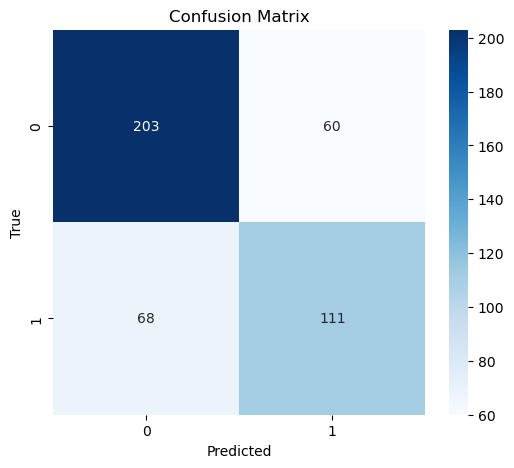

In [67]:
# Generate confusion matrix
rf_cm = confusion_matrix(y_holdout, test_preds)


# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Best Model

In [68]:
skf = StratifiedKFold(n_splits=5)

RF ={}

test_rec_scores = []
test_accuracy_scores = []
test_auc_scores = []
test_pr_auc_scores = []
test_precision_scores = []
test_spec_scores = []
test_spec_sens = []



pipeline_init_rf = Pipeline([
    ('RandomOverSampler', RandomOverSampler(random_state=6)),
    ('RandomForestClassifier', RandomForestClassifier(
        bootstrap=True,
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=200,
        random_state=6
    ))
    ])


pipeline_init_rf.fit(X_trainval, y_trainval)


train_preds = pipeline_init_rf.predict(X_trainval)
test_preds = pipeline_init_rf.predict(X_holdout)
test_proba = pipeline_init_rf.predict_proba(X_holdout)[:, 1]

test_rec_score = sensitivity_score(y_holdout, test_preds)
test_accuracy_score = accuracy_score(y_holdout, test_preds)
test_auc_score = roc_auc_score(y_holdout, test_proba)
test_pr_auc_score = average_precision_score(y_holdout, test_proba)
test_precision_score = precision_score(y_holdout, test_preds)

# Calculate specificity
tn, fp, fn, tp = confusion_matrix(y_holdout, test_preds).ravel()
val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
val_total_spec_sens = val_spec_score + test_rec_score

test_rec_scores.append(test_rec_score)
test_accuracy_scores.append(test_accuracy_score)
test_auc_scores.append(test_auc_score)
test_pr_auc_scores.append(test_pr_auc_score)
test_precision_scores.append(test_precision_score)
test_spec_scores.append(val_spec_score)
test_spec_sens.append(val_total_spec_sens)

RF['RFClassifier'] = {
    'ave_test_recall':np.mean(test_rec_scores) * 100,
    'ave_test_accuracy_score':np.mean(test_accuracy_scores) * 100,
    'ave_test_auc_score': np.mean(test_auc_scores) * 100,
    'ave_test_pr_auc_score': np.mean(test_pr_auc_scores) * 100,
    'ave_test_precision_score': np.mean(test_precision_scores) * 100,
    'ave_val_specificity': np.mean(test_spec_scores) * 100,  # Average specificity
    'Specificity + Sensitivity': (np.mean(test_spec_sens) * 100),

}

RF = pd.DataFrame(RF).T
display(RF)

,Specificity + Sensitivity,ave_test_accuracy_score,ave_test_auc_score,ave_test_pr_auc_score,ave_test_precision_score,ave_test_recall,ave_val_specificity
RFClassifier,145.032606,73.9819,79.652484,74.319775,69.047619,64.804469,80.228137


## Male

In [69]:
X, y = df_male.drop(['SOURCE', 'SEX'], axis=1), df_male['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
3673,44.0,14.8,5.03,9.2,333,29.4,33.6,87.5,69
415,35.1,11.9,3.91,6.6,277,30.4,33.9,89.8,17
1190,46.0,15.9,5.26,6.8,317,30.2,34.6,87.5,30
3499,39.7,13.5,4.72,4.6,186,28.6,34.0,84.1,67
4143,31.2,11.1,3.03,10.8,179,36.6,35.6,103.0,78
...,...,...,...,...,...,...,...,...,...
130,38.8,13.5,5.17,4.8,270,26.1,34.8,75.0,5
1581,49.6,16.8,5.86,10.5,310,28.7,33.9,84.6,37
2503,28.8,9.8,3.41,15.7,181,28.7,34.0,84.5,53
2032,37.9,13.1,4.40,4.7,84,29.8,34.6,86.1,45


In [70]:
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
3673,44.0,14.8,5.03,9.2,333,29.4,33.6,87.5,69
415,35.1,11.9,3.91,6.6,277,30.4,33.9,89.8,17
1190,46.0,15.9,5.26,6.8,317,30.2,34.6,87.5,30
3499,39.7,13.5,4.72,4.6,186,28.6,34.0,84.1,67
4143,31.2,11.1,3.03,10.8,179,36.6,35.6,103.0,78
...,...,...,...,...,...,...,...,...,...
130,38.8,13.5,5.17,4.8,270,26.1,34.8,75.0,5
1581,49.6,16.8,5.86,10.5,310,28.7,33.9,84.6,37
2503,28.8,9.8,3.41,15.7,181,28.7,34.0,84.5,53
2032,37.9,13.1,4.40,4.7,84,29.8,34.6,86.1,45


### RF

In [71]:
param_grid_rf = {
    'RandomForestClassifier__n_estimators': [50, 100, 200],
    'RandomForestClassifier__max_depth': [None, 10, 20, 30],
    'RandomForestClassifier__min_samples_split': [2, 5, 10],
    'RandomForestClassifier__min_samples_leaf': [1, 2, 4],
    'RandomForestClassifier__max_features': ['sqrt', 'log2'],
    'RandomForestClassifier__bootstrap': [True, False]
}

In [72]:
skf = StratifiedKFold(n_splits=5)

RF_male ={}

test_rec_scores = []
test_accuracy_scores = []
test_auc_scores = []
test_pr_auc_scores = []
test_precision_scores = []
test_spec_scores = []
test_spec_sens = []



pipeline_init_rf = Pipeline([
                        ('SMOTEr', SMOTE(random_state=6)),
                        ('RandomForestClassifier', RandomForestClassifier(random_state=6))])

grid_search = GridSearchCV(
    estimator=pipeline_init_rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_trainval, y_trainval)
pipeline = grid_search.best_estimator_

train_preds = pipeline.predict(X_trainval)
test_preds = pipeline.predict(X_holdout)
test_proba = pipeline.predict_proba(X_holdout)[:, 1]

test_rec_score = sensitivity_score(y_holdout, test_preds)
test_accuracy_score = accuracy_score(y_holdout, test_preds)
test_auc_score = roc_auc_score(y_holdout, test_proba)
test_pr_auc_score = average_precision_score(y_holdout, test_proba)
test_precision_score = precision_score(y_holdout, test_preds)

# Calculate specificity
tn, fp, fn, tp = confusion_matrix(y_holdout, test_preds).ravel()

val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
val_total_spec_sens = val_spec_score + test_rec_score

test_rec_scores.append(test_rec_score)
test_accuracy_scores.append(test_accuracy_score)
test_auc_scores.append(test_auc_score)
test_pr_auc_scores.append(test_pr_auc_score)
test_precision_scores.append(test_precision_score)
test_spec_scores.append(val_spec_score)
test_spec_sens.append(val_total_spec_sens)

RF_male['RFClassifier'] = {
    'ave_test_recall':np.mean(test_rec_scores) * 100,
    'ave_test_accuracy_score':np.mean(test_accuracy_scores) * 100,
    'ave_test_auc_score': np.mean(test_auc_scores) * 100,
    'ave_test_pr_auc_score': np.mean(test_pr_auc_scores) * 100,
    'ave_test_precision_score': np.mean(test_precision_scores) * 100,
    'ave_val_specificity': np.mean(test_spec_scores) * 100,  # Average specificity
    'Specificity + Sensitivity': (np.mean(test_spec_sens) * 100),

}

RF_male = pd.DataFrame(RF_male).T
display(RF_male)
print(grid_search.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,Specificity + Sensitivity,ave_test_accuracy_score,ave_test_auc_score,ave_test_pr_auc_score,ave_test_precision_score,ave_test_recall,ave_val_specificity
RFClassifier,148.527808,74.672489,79.256894,73.321877,70.0,71.428571,77.099237


{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': 10, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 1, 'RandomForestClassifier__min_samples_split': 5, 'RandomForestClassifier__n_estimators': 50}


## Female

In [73]:
X, y = df_female.drop(['SOURCE', 'SEX'], axis=1), df_female['SOURCE']

(X_trainval, X_holdout, y_trainval, y_holdout) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
2960,39.8,13.2,4.40,8.5,362,30.0,33.2,90.5,59
273,36.8,12.7,4.83,9.7,286,26.3,34.5,76.2,11
1111,39.2,13.5,4.62,3.0,150,29.2,34.4,84.8,30
4002,33.1,10.7,3.74,8.0,450,28.6,32.3,88.5,75
965,31.0,10.0,3.83,9.7,202,26.1,32.3,80.9,27
...,...,...,...,...,...,...,...,...,...
3378,32.4,10.7,3.87,18.2,466,27.6,33.0,83.7,65
3468,34.4,11.4,3.57,4.2,222,31.9,33.1,96.4,66
1242,35.3,12.2,4.15,9.6,273,29.4,34.6,85.1,32
1106,32.8,10.7,3.69,7.5,315,29.0,32.6,88.9,29


### RF

In [74]:
param_grid_rf = {
    'RandomForestClassifier__n_estimators': [50, 100, 200],
    'RandomForestClassifier__max_depth': [None, 10, 20, 30],
    'RandomForestClassifier__min_samples_split': [2, 5, 10],
    'RandomForestClassifier__min_samples_leaf': [1, 2, 4],
    'RandomForestClassifier__max_features': ['sqrt', 'log2'],
    'RandomForestClassifier__bootstrap': [True, False]
}

In [75]:
skf = StratifiedKFold(n_splits=5)

RF_female ={}

test_rec_scores = []
test_accuracy_scores = []
test_auc_scores = []
test_pr_auc_scores = []
test_precision_scores = []
test_spec_scores = []
test_spec_sens = []



pipeline_init_rf = Pipeline([
                        ('SMOTEr', SMOTE(random_state=6)),
                        ('RandomForestClassifier', RandomForestClassifier(random_state=6))])

grid_search = GridSearchCV(
    estimator=pipeline_init_rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_trainval, y_trainval)
pipeline = grid_search.best_estimator_

train_preds = pipeline.predict(X_trainval)
test_preds = pipeline.predict(X_holdout)
test_proba = pipeline.predict_proba(X_holdout)[:, 1]

test_rec_score = sensitivity_score(y_holdout, test_preds)
test_accuracy_score = accuracy_score(y_holdout, test_preds)
test_auc_score = roc_auc_score(y_holdout, test_proba)
test_pr_auc_score = average_precision_score(y_holdout, test_proba)
test_precision_score = precision_score(y_holdout, test_preds)

# Calculate specificity
tn, fp, fn, tp = confusion_matrix(y_holdout, test_preds).ravel()
val_spec_score = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
val_total_spec_sens = val_spec_score + test_rec_score

test_rec_scores.append(test_rec_score)
test_accuracy_scores.append(test_accuracy_score)
test_auc_scores.append(test_auc_score)
test_pr_auc_scores.append(test_pr_auc_score)
test_precision_scores.append(test_precision_score)
test_spec_scores.append(val_spec_score)
test_spec_sens.append(val_total_spec_sens)

RF_female['RFClassifier'] = {
    'ave_test_recall':np.mean(test_rec_scores) * 100,
    'ave_test_accuracy_score':np.mean(test_accuracy_scores) * 100,
    'ave_test_auc_score': np.mean(test_auc_scores) * 100,
    'ave_test_pr_auc_score': np.mean(test_pr_auc_scores) * 100,
    'ave_test_precision_score': np.mean(test_precision_scores) * 100,
    'ave_val_specificity': np.mean(test_spec_scores) * 100,  # Average specificity
    'Specificity + Sensitivity': (np.mean(test_spec_sens) * 100),

}

RF_female = pd.DataFrame(RF_female).T
display(RF_female)
print(grid_search.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,Specificity + Sensitivity,ave_test_accuracy_score,ave_test_auc_score,ave_test_pr_auc_score,ave_test_precision_score,ave_test_recall,ave_val_specificity
RFClassifier,145.735129,74.647887,79.05911,73.951619,67.088608,65.432099,80.30303


{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': 10, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 4, 'RandomForestClassifier__min_samples_split': 2, 'RandomForestClassifier__n_estimators': 100}


# Interpretability of Best Models

## All

In [165]:
X, y = df.drop(['SOURCE'], axis=1), df['SOURCE']

(X_trainval_a, X_holdout_a, y_trainval_a, y_holdout_a) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)

In [245]:
{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': None, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 4, 'RandomForestClassifier__min_samples_split': 10, 'RandomForestClassifier__n_estimators': 200}

{'RandomForestClassifier__bootstrap': True,
 'RandomForestClassifier__max_depth': None,
 'RandomForestClassifier__max_features': 'sqrt',
 'RandomForestClassifier__min_samples_leaf': 4,
 'RandomForestClassifier__min_samples_split': 10,
 'RandomForestClassifier__n_estimators': 200}

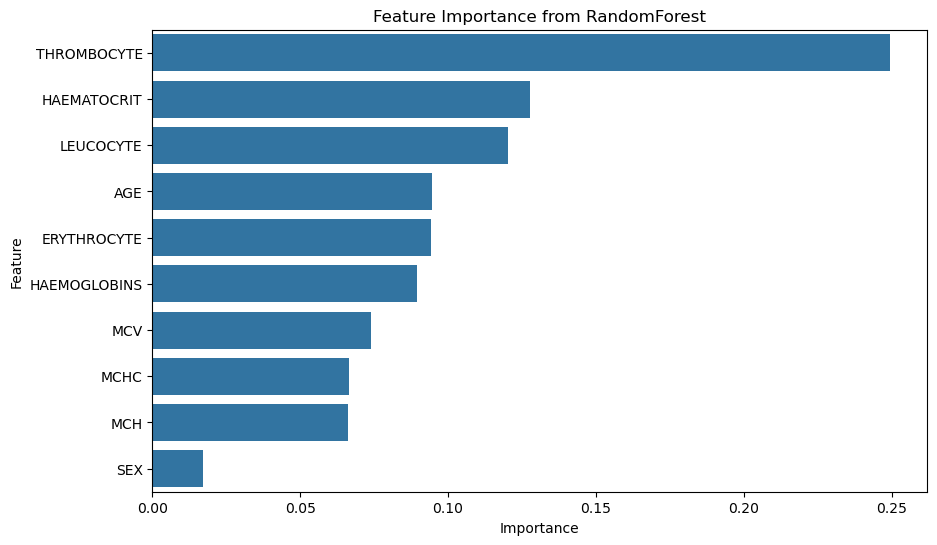

In [221]:
model_a =RandomForestClassifier(
        bootstrap=True,
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=200,
        random_state=6
    )

Ppln_a = Pipeline([('RandomOverSampler', RandomOverSampler(random_state=6)),
                   ('RandomForestClassifier', model_a)])

Ppln_a.fit(X_trainval_a, y_trainval_a)
model_a = Ppln_a.named_steps['RandomForestClassifier']

feature_importances_a = model_a.feature_importances_

# Create a DataFrame for visualization
feature_names_a = X_holdout_a.columns
importance_df_a = pd.DataFrame({
    'Feature': feature_names_a,
    'Importance': feature_importances_a
})


importance_df_a = importance_df_a.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_a)
plt.title('Feature Importance from RandomForest')
plt.show()

## Male

In [113]:
X, y = df_male.drop(['SOURCE', 'SEX'], axis=1), df_male['SOURCE']

(X_trainval_m, X_holdout_m, y_trainval_m, y_holdout_m) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval_m

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
3673,44.0,14.8,5.03,9.2,333,29.4,33.6,87.5,69
415,35.1,11.9,3.91,6.6,277,30.4,33.9,89.8,17
1190,46.0,15.9,5.26,6.8,317,30.2,34.6,87.5,30
3499,39.7,13.5,4.72,4.6,186,28.6,34.0,84.1,67
4143,31.2,11.1,3.03,10.8,179,36.6,35.6,103.0,78
...,...,...,...,...,...,...,...,...,...
130,38.8,13.5,5.17,4.8,270,26.1,34.8,75.0,5
1581,49.6,16.8,5.86,10.5,310,28.7,33.9,84.6,37
2503,28.8,9.8,3.41,15.7,181,28.7,34.0,84.5,53
2032,37.9,13.1,4.40,4.7,84,29.8,34.6,86.1,45


In [114]:
{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': 10, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 1, 'RandomForestClassifier__min_samples_split': 5, 'RandomForestClassifier__n_estimators': 50}

{'RandomForestClassifier__bootstrap': True,
 'RandomForestClassifier__max_depth': 10,
 'RandomForestClassifier__max_features': 'sqrt',
 'RandomForestClassifier__min_samples_leaf': 1,
 'RandomForestClassifier__min_samples_split': 5,
 'RandomForestClassifier__n_estimators': 50}

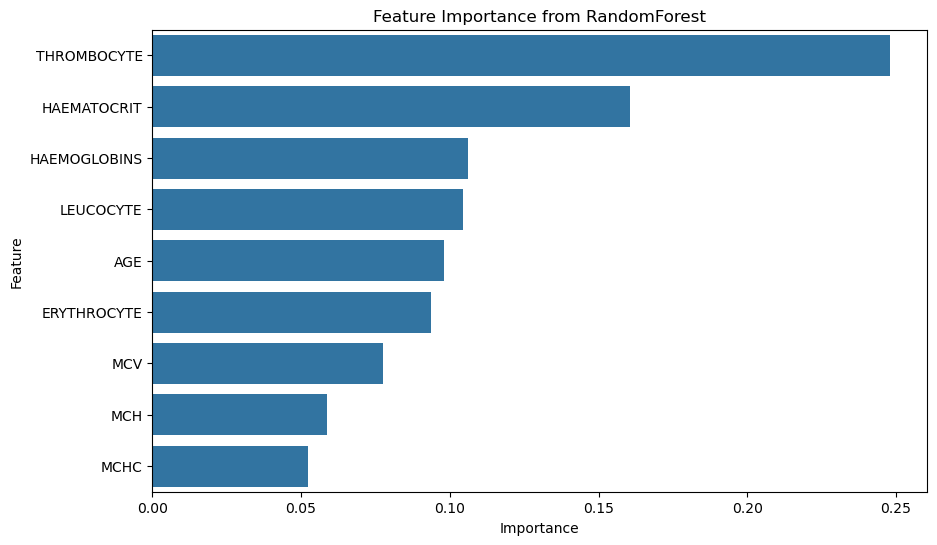

In [222]:
model_m =RandomForestClassifier(
        bootstrap=True,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=50,
        random_state=6
    )

Ppln_m = Pipeline([('SMOTEr', SMOTE(random_state=6)),
                   ('RandomForestClassifier', model_m)])

Ppln_m.fit(X_trainval_m, y_trainval_m)
model_m = Ppln_m.named_steps['RandomForestClassifier']

feature_importances_m = model_m.feature_importances_

# Create a DataFrame for visualization
feature_names_m = X_holdout_m.columns
importance_df_m = pd.DataFrame({
    'Feature': feature_names_m,
    'Importance': feature_importances_m
})


importance_df_m = importance_df_m.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_m)
plt.title('Feature Importance from RandomForest')
plt.show()

## Female

In [117]:
X, y = df_female.drop(['SOURCE', 'SEX'], axis=1), df_female['SOURCE']

(X_trainval_f, X_holdout_f, y_trainval_f, y_holdout_f) = train_test_split(X, y,
                                                                  shuffle = True,
                                                                  random_state=6,
                                                                  test_size=0.1,
                                                                  stratify=y)
X_trainval_f

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
2960,39.8,13.2,4.40,8.5,362,30.0,33.2,90.5,59
273,36.8,12.7,4.83,9.7,286,26.3,34.5,76.2,11
1111,39.2,13.5,4.62,3.0,150,29.2,34.4,84.8,30
4002,33.1,10.7,3.74,8.0,450,28.6,32.3,88.5,75
965,31.0,10.0,3.83,9.7,202,26.1,32.3,80.9,27
...,...,...,...,...,...,...,...,...,...
3378,32.4,10.7,3.87,18.2,466,27.6,33.0,83.7,65
3468,34.4,11.4,3.57,4.2,222,31.9,33.1,96.4,66
1242,35.3,12.2,4.15,9.6,273,29.4,34.6,85.1,32
1106,32.8,10.7,3.69,7.5,315,29.0,32.6,88.9,29


In [119]:
{'RandomForestClassifier__bootstrap': True, 'RandomForestClassifier__max_depth': 10, 'RandomForestClassifier__max_features': 'sqrt', 'RandomForestClassifier__min_samples_leaf': 4, 'RandomForestClassifier__min_samples_split': 2, 'RandomForestClassifier__n_estimators': 100}

{'RandomForestClassifier__bootstrap': True,
 'RandomForestClassifier__max_depth': 10,
 'RandomForestClassifier__max_features': 'sqrt',
 'RandomForestClassifier__min_samples_leaf': 4,
 'RandomForestClassifier__min_samples_split': 2,
 'RandomForestClassifier__n_estimators': 100}

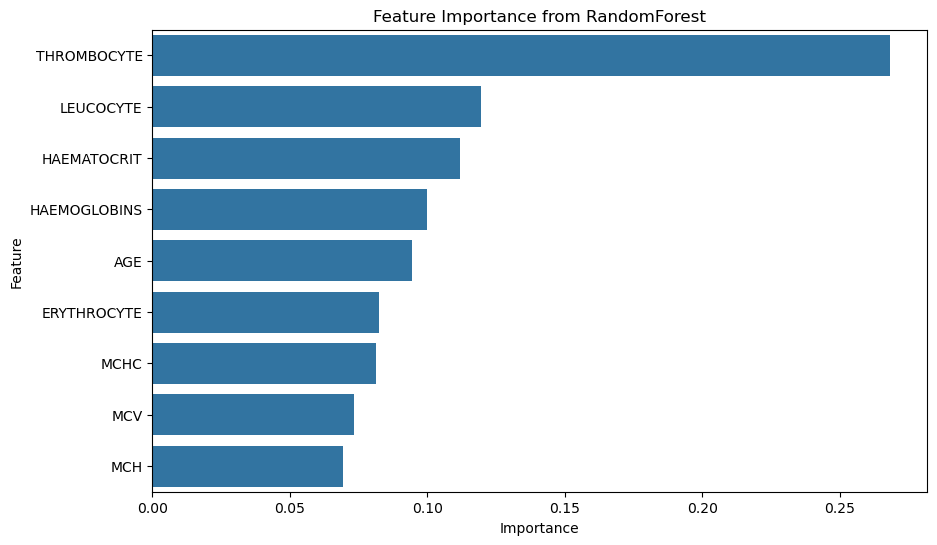

In [223]:
model_f =RandomForestClassifier(
        bootstrap=True,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=4,
        min_samples_split=2,
        n_estimators=100,
        random_state=6
    )

Ppln_f = Pipeline([('SMOTEr', SMOTE(random_state=6)),
                   ('RandomForestClassifier', model_f)])

Ppln_f.fit(X_trainval_f, y_trainval_f)
model_f = Ppln_f.named_steps['RandomForestClassifier']

# model_f.fit(X_trainval, y_trainval)

feature_importances_f = model_f.feature_importances_

# Create a DataFrame for visualization
feature_names_f = X_holdout_f.columns
importance_df_f = pd.DataFrame({
    'Feature': feature_names_f,
    'Importance': feature_importances_f
})

importance_df_f = importance_df_f.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_f)
plt.title('Feature Importance from RandomForest')
plt.show()

## SHAP

### All

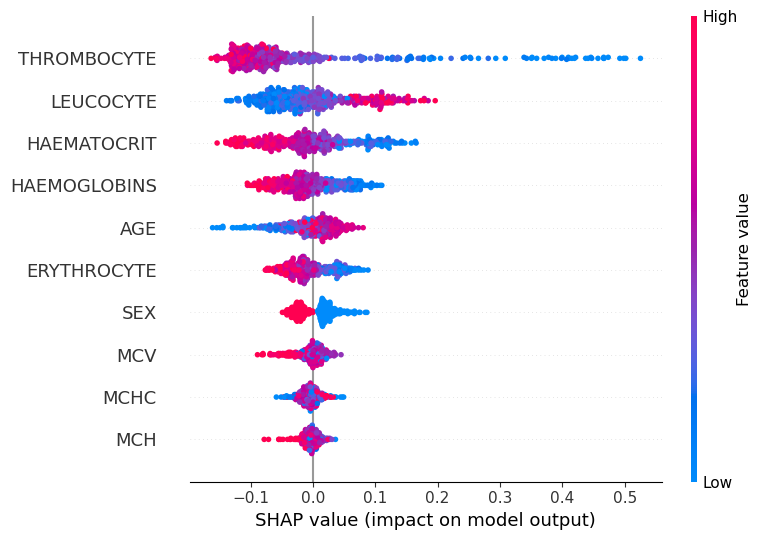

In [224]:
import shap

# Use SHAP TreeExplainer
explainer_a = shap.TreeExplainer(model_a)
shap_values_a = explainer_a.shap_values(X_holdout_a)

# Visualize feature importance
shap.summary_plot(shap_values_a[:,:,1], X_holdout_a)

#### For local explanation

In [225]:
y_holdout_a

2706    1
4368    1
2591    1
57      0
3682    0
       ..
1809    1
4351    1
2446    0
3932    0
614     0
Name: SOURCE, Length: 442, dtype: int64

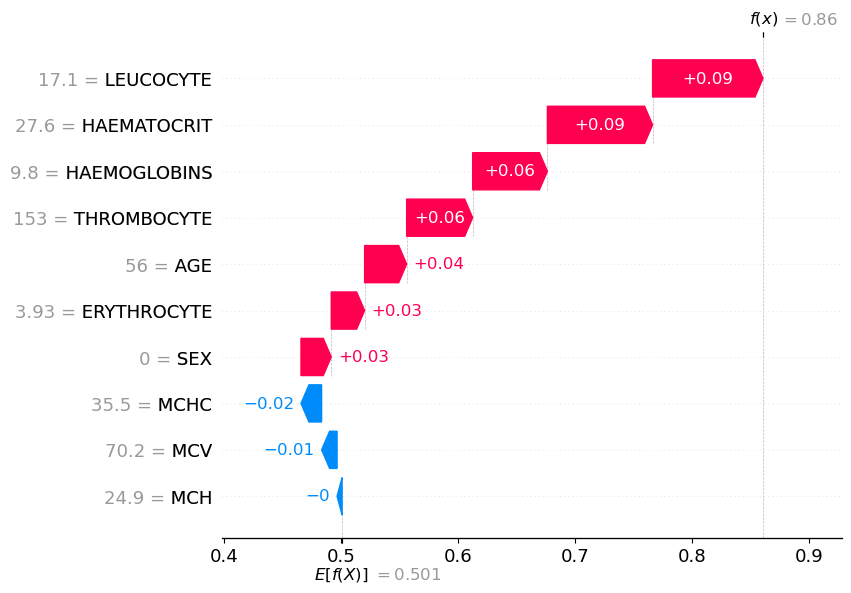

In [226]:
shap.waterfall_plot(
    shap.Explanation(values=shap_values_a[0,:,1],
                     base_values=explainer_a.expected_value[1],
                     data=X_holdout_a.iloc[0],
                     feature_names=X_holdout_a.columns)
)

In [227]:
y_holdout_a.loc[4269] # same as the one used in the Male-specific model

1

In [228]:
y_holdout_a.index.get_loc(4269)

119

In [229]:
X_holdout_a.loc[4269]

HAEMATOCRIT      39.90
HAEMOGLOBINS     13.00
ERYTHROCYTE       4.88
LEUCOCYTE        21.90
THROMBOCYTE     133.00
MCH              26.60
MCHC             32.60
MCV              81.80
AGE              83.00
SEX               0.00
Name: 4269, dtype: float64

In [230]:
X_holdout_a.iloc[119] == X_holdout_a.loc[4269]

HAEMATOCRIT     True
HAEMOGLOBINS    True
ERYTHROCYTE     True
LEUCOCYTE       True
THROMBOCYTE     True
MCH             True
MCHC            True
MCV             True
AGE             True
SEX             True
Name: 4269, dtype: bool

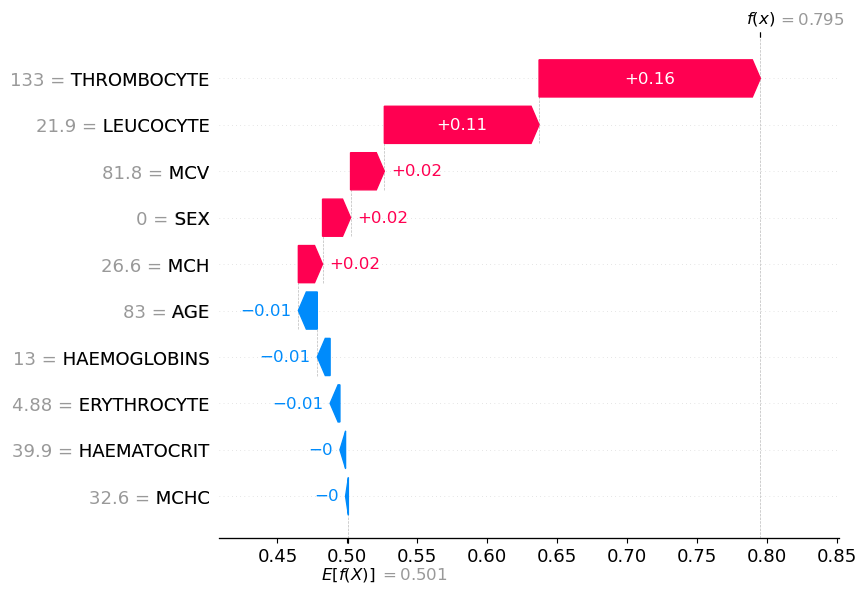

In [231]:
shap.waterfall_plot(
    shap.Explanation(values=shap_values_a[119,:,1],
                     base_values=explainer_a.expected_value[1],
                     data=X_holdout_a.iloc[119],
                     feature_names=X_holdout_a.columns)
)

### Male

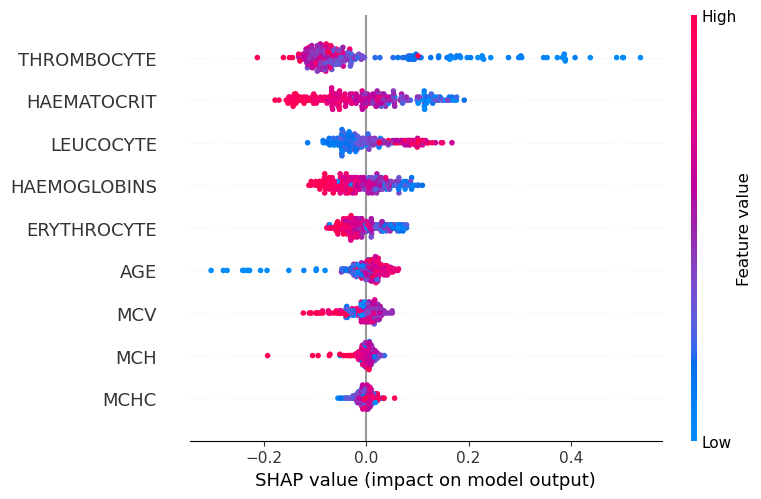

In [232]:
# Use SHAP TreeExplainer
explainer_m = shap.TreeExplainer(model_m)
shap_values_m = explainer_m.shap_values(X_holdout_m)

# Visualize feature importance
shap.summary_plot(shap_values_m[:,:,1], X_holdout_m)

#### For local explanation

In [233]:
y_holdout_m

420     0
663     0
4269    1
3580    0
1977    0
       ..
2301    0
190     0
1911    0
4024    1
2929    0
Name: SOURCE, Length: 229, dtype: int64

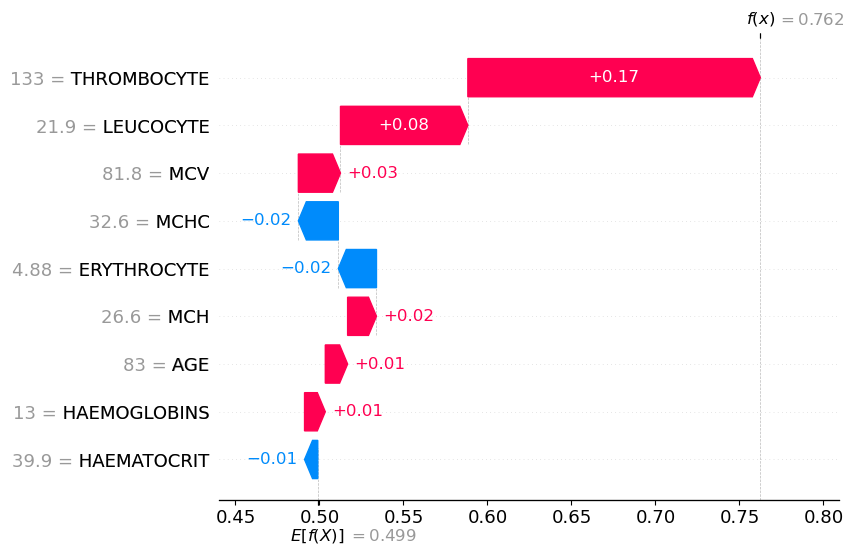

In [234]:
shap.waterfall_plot(
    shap.Explanation(values=shap_values_m[2,:,1],
                     base_values=explainer_m.expected_value[1],
                     data=X_holdout_m.iloc[2],
                     feature_names=X_holdout_m.columns)
)

### Female

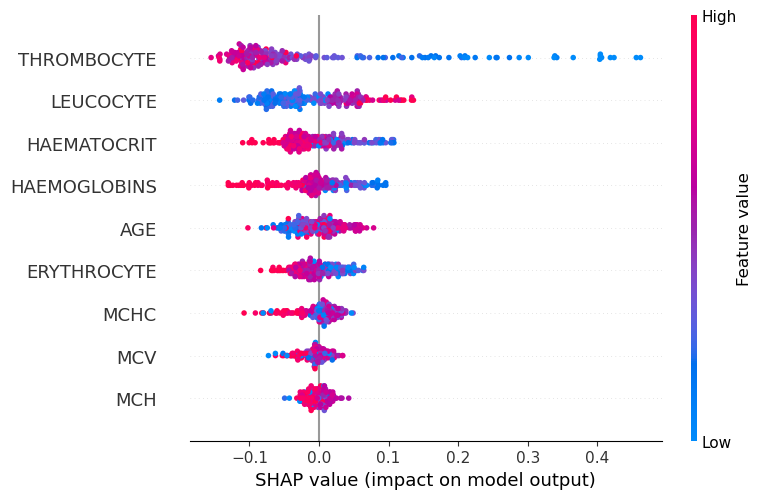

In [235]:
# Use SHAP TreeExplainer
explainer_f = shap.TreeExplainer(model_f)
shap_values_f = explainer_f.shap_values(X_holdout_f)

# Visualize feature importance
shap.summary_plot(shap_values_f[:,:,1], X_holdout_f)

#### For local explanation

In [236]:
y_holdout_f

2963    0
975     0
3171    0
1375    0
2401    1
       ..
3329    0
1792    0
4340    0
744     0
3763    0
Name: SOURCE, Length: 213, dtype: int64

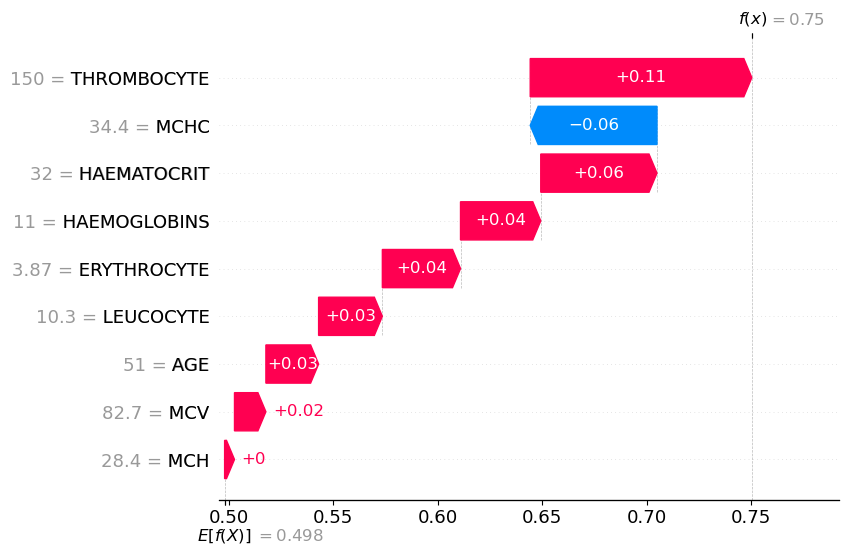

In [237]:
shap.waterfall_plot(
    shap.Explanation(values=shap_values_f[4,:,1],
                     base_values=explainer_f.expected_value[1],
                     data=X_holdout_f.iloc[4],
                     feature_names=X_holdout_f.columns)
)

## Calc of Thresholds

In [191]:
from sklearn.metrics import confusion_matrix

In [190]:
# model_a.predict(X_holdout_a)

array([1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

In [189]:
# model_a.predict_proba(X_holdout_a)

array([[0.14722748, 0.85277252],
       [0.40745417, 0.59254583],
       [0.21964628, 0.78035372],
       [0.6013668 , 0.3986332 ],
       [0.43253809, 0.56746191],
       [0.11693341, 0.88306659],
       [0.67244749, 0.32755251],
       [0.67836703, 0.32163297],
       [0.72533975, 0.27466025],
       [0.87301504, 0.12698496],
       [0.60423327, 0.39576673],
       [0.72826447, 0.27173553],
       [0.94631724, 0.05368276],
       [0.20740252, 0.79259748],
       [0.55894997, 0.44105003],
       [0.45117572, 0.54882428],
       [0.89045525, 0.10954475],
       [0.81852809, 0.18147191],
       [0.72302697, 0.27697303],
       [0.06448603, 0.93551397],
       [0.88551113, 0.11448887],
       [0.69595931, 0.30404069],
       [0.83923353, 0.16076647],
       [0.84770211, 0.15229789],
       [0.63278226, 0.36721774],
       [0.73932021, 0.26067979],
       [0.56051565, 0.43948435],
       [0.05689482, 0.94310518],
       [0.1305291 , 0.8694709 ],
       [0.84085407, 0.15914593],
       [0.

In [238]:
y_pred_a_prob = model_a.predict_proba(X_holdout_a)[:, 1]
y_pred_a_prob

array([0.86031215, 0.64433347, 0.81806068, 0.47166736, 0.60912276,
       0.89048531, 0.46663069, 0.33066362, 0.33322503, 0.22085601,
       0.3783001 , 0.30196765, 0.11002379, 0.80588326, 0.47902563,
       0.59065137, 0.15759606, 0.27571958, 0.31810588, 0.94730593,
       0.1293162 , 0.33213555, 0.17104722, 0.22582986, 0.43288602,
       0.34354811, 0.52180804, 0.94491856, 0.86622813, 0.22297888,
       0.91713927, 0.66394374, 0.70254064, 0.70695908, 0.89289159,
       0.31485837, 0.37790635, 0.29069607, 0.20098067, 0.3212313 ,
       0.75849963, 0.81918889, 0.38263074, 0.14179475, 0.42002774,
       0.2698446 , 0.80148335, 0.22899927, 0.39065858, 0.30725735,
       0.61832896, 0.08580678, 0.16276575, 0.41653261, 0.4591343 ,
       0.20034234, 0.74934929, 0.46640685, 0.29066395, 0.48001294,
       0.35822343, 0.16857134, 0.41830033, 0.6511178 , 0.33943586,
       0.23772196, 0.4942847 , 0.19958526, 0.16303003, 0.27537834,
       0.58559239, 0.3573798 , 0.19716462, 0.69706355, 0.43029

In [239]:
y_pred_a_prob = model_a.predict_proba(X_holdout_a)[:, 1]

threshold_a_upper = 0.5
while threshold_a_upper < 1:
    y_pred_a = np.array([1 if x >= threshold_a_upper else 0 for x in y_pred_a_prob])
    cm = confusion_matrix(y_holdout_a, y_pred_a)
    if cm[1, 1]/(cm[1, 1]+cm[0, 1]) >= 0.99:
        break
    threshold_a_upper += 0.01
    
print(threshold_a_upper)
cm_a_upper = cm
print(cm_a_upper)

threshold_a_lower = 0.5
while threshold_a_lower > 0:
    y_pred_a = np.array([1 if x >= threshold_a_lower else 0 for x in y_pred_a_prob])
    cm = confusion_matrix(y_holdout_a, y_pred_a)
    if cm[0, 0]/(cm[0, 0]+cm[1, 0]) >= 0.99:
        break
    threshold_a_lower -= 0.01
    
print(threshold_a_lower)
cm_a_lower = cm
print(cm_a_lower)

0.9500000000000004
[[263   0]
 [173   6]]
0.0699999999999997
[[  4 259]
 [  0 179]]


In [240]:
(cm_a_upper[1, 1] + cm_a_lower[0, 0])/np.sum(cm_a_lower)*100

2.262443438914027

In [241]:
y_pred_m_prob = model_m.predict_proba(X_holdout_m)[:, 1]

threshold_m_upper = 0.5
while threshold_m_upper < 1:
    y_pred_m = np.array([1 if x >= threshold_m_upper else 0 for x in y_pred_m_prob])
    cm = confusion_matrix(y_holdout_m, y_pred_m)
    if cm[1, 1]/(cm[1, 1]+cm[0, 1]) >= 0.99:
        break
    threshold_m_upper += 0.01
    
print(threshold_m_upper)
cm_m_upper = cm
print(cm_m_upper)

threshold_m_lower = 0.5
while threshold_m_lower > 0:
    y_pred_m = np.array([1 if x >= threshold_m_lower else 0 for x in y_pred_m_prob])
    cm = confusion_matrix(y_holdout_m, y_pred_m)
    if cm[0, 0]/(cm[0, 0]+cm[1, 0]) >= 0.99:
        break
    threshold_m_lower -= 0.01
    
print(threshold_m_lower)
cm_m_lower = cm
print(cm_m_lower)

0.9700000000000004
[[131   0]
 [ 96   2]]
0.08999999999999969
[[ 10 121]
 [  0  98]]


In [242]:
(cm_m_upper[1, 1] + cm_m_lower[0, 0])/np.sum(cm_m_lower)*100

5.240174672489083

In [243]:
y_pred_f_prob = model_f.predict_proba(X_holdout_f)[:, 1]

threshold_f_upper = 0.5
while threshold_f_upper < 1:
    y_pred_f = np.array([1 if x >= threshold_f_upper else 0 for x in y_pred_f_prob])
    cm = confusion_matrix(y_holdout_f, y_pred_f)
    if cm[1, 1]/(cm[1, 1]+cm[0, 1]) >= 0.99:
        break
    threshold_f_upper += 0.01
    
print(threshold_f_upper)
cm_f_upper = cm
print(cm_f_upper)

threshold_f_lower = 0.5
while threshold_f_lower > 0:
    y_pred_f = np.array([1 if x >= threshold_f_lower else 0 for x in y_pred_f_prob])
    cm = confusion_matrix(y_holdout_f, y_pred_f)
    if cm[0, 0]/(cm[0, 0]+cm[1, 0]) >= 0.99:
        break
    threshold_f_lower -= 0.01
    
print(threshold_f_lower)
cm_f_lower = cm
print(cm_f_lower)

0.8200000000000003
[[132   0]
 [ 67  14]]
0.12999999999999967
[[  6 126]
 [  0  81]]


In [244]:
(cm_f_upper[1, 1] + cm_f_lower[0, 0])/np.sum(cm_f_lower)*100

9.389671361502346

#### Predictions per model

In [179]:
X_a, y_a = df.drop(['SOURCE'], axis=1), df['SOURCE']

In [180]:
model_a.predict(X_holdout_a)

array([1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

In [181]:
y_holdout_a

2706    1
4368    1
2591    1
57      0
3682    0
       ..
1809    1
4351    1
2446    0
3932    0
614     0
Name: SOURCE, Length: 442, dtype: int64

In [184]:
df_holdout_a = X_holdout_a.copy(deep=True)
df_holdout_a['SOURCE'] = y_holdout_a
df_holdout_a['SOURCE (pred)'] = model_a.predict(X_holdout_a)
df_holdout_a.to_csv('df_holdout_all.csv', index=False)
df_holdout_a

In [185]:
df_holdout_m = X_holdout_m.copy(deep=True)
df_holdout_m['SOURCE'] = y_holdout_m
df_holdout_m['SOURCE (pred)'] = model_m.predict(X_holdout_m)
df_holdout_m.to_csv('df_holdout_male.csv', index=False)
df_holdout_m

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE,SOURCE (pred)
420,44.5,13.8,6.33,22.5,398,21.8,31.0,70.3,17,0,0
663,46.0,15.2,5.51,6.8,308,27.6,33.0,83.5,23,0,0
4269,39.9,13.0,4.88,21.9,133,26.6,32.6,81.8,83,1,1
3580,36.6,10.6,5.48,10.1,567,19.3,29.0,66.8,68,0,0
1977,30.6,9.9,3.51,8.1,504,28.2,32.4,87.2,44,0,1
...,...,...,...,...,...,...,...,...,...,...,...
2301,44.0,15.1,5.20,6.8,336,29.0,34.3,84.6,49,0,0
190,34.2,11.5,4.59,27.0,298,25.1,33.6,74.5,7,0,0
1911,52.6,17.5,6.22,5.4,260,28.1,33.3,84.6,43,0,0
4024,21.7,7.5,2.47,10.1,67,30.4,34.6,87.9,76,1,1


In [186]:
df_holdout_f = X_holdout_f.copy(deep=True)
df_holdout_f['SOURCE'] = y_holdout_f
df_holdout_f['SOURCE (pred)'] = model_f.predict(X_holdout_f)
df_holdout_f.to_csv('df_holdout_female.csv', index=False)
df_holdout_f

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE,SOURCE (pred)
2963,39.0,12.6,4.59,5.7,322,27.5,32.3,85.0,59,0,0
975,38.9,12.3,4.25,5.7,263,28.9,31.6,91.5,27,0,0
3171,48.4,16.0,5.67,3.0,60,28.2,33.1,85.4,62,0,1
1375,37.5,12.6,3.98,12.9,232,31.7,33.6,94.2,33,0,1
2401,32.0,11.0,3.87,10.3,150,28.4,34.4,82.7,51,1,1
...,...,...,...,...,...,...,...,...,...,...,...
3329,38.9,12.5,4.53,5.1,129,27.6,32.1,85.9,65,0,1
1792,29.9,8.9,4.43,5.8,397,20.1,29.8,67.5,41,0,0
4340,38.6,13.0,3.77,17.5,173,34.5,33.7,102.4,87,0,1
744,41.5,14.0,4.95,8.6,357,28.3,33.7,83.8,24,0,0


In [188]:
df_holdout_f.sum(axis=0)

HAEMATOCRIT       7755.8
HAEMOGLOBINS      2560.2
ERYTHROCYTE        922.7
LEUCOCYTE         1755.9
THROMBOCYTE      57735.0
MCH               5953.4
MCHC              7028.5
MCV              18021.6
AGE               9883.0
SOURCE              81.0
SOURCE (pred)       60.0
dtype: float64

#### Other Trials

## LIME

In [248]:
# !pip install lime
from lime.lime_tabular import LimeTabularExplainer

### All - local

In [251]:
# Initialize the LimeTabularExplainer with feature names
lime_explainer_a = LimeTabularExplainer(
    X_trainval_a.values,  # Training data without target values
    feature_names=X_trainval_a.columns.tolist(),  # Feature names
    class_names=['Out Patient Care', 'In Patient Care'],  # Optional: you can name your target classes
    verbose=True,
    mode='classification'  # Assuming you're doing classification
)

instance = X_holdout_a.iloc[[119]]  # Keep it as a DataFrame for feature consistency

# Define a prediction function that maintains feature names to avoid the warning
def prediction_with_names_a(data):
    # Convert the data back to a DataFrame with appropriate column names
    data_df = pd.DataFrame(data, columns=X_holdout_a.columns)
    return Ppln_a.predict_proba(data_df)

# Use LIME to explain the prediction for this instance
lime_exp = lime_explainer_a.explain_instance(
    instance.values[0],         # Pass the instance as an array
    prediction_with_names_a,      # Custom prediction function
    num_features=10             # Number of features to include in the explanation
)

# Visualize the explanation
lime_exp.show_in_notebook(show_table=True)

Intercept 0.3667765135038393
Prediction_local [0.77543143]
Right: 0.7950847175700114


### Male - local

In [252]:
# Initialize the LimeTabularExplainer with feature names
lime_explainer_m = LimeTabularExplainer(
    X_trainval_m.values,  # Training data without target values
    feature_names=X_trainval_m.columns.tolist(),  # Feature names
    class_names=['Out Patient Care', 'In Patient Care'],  # Optional: you can name your target classes
    verbose=True,
    mode='classification'  # Assuming you're doing classification
)

instance_m = X_holdout_m.iloc[[2]]  # Keep it as a DataFrame for feature consistency

# Define a prediction function that maintains feature names to avoid the warning
def prediction_with_names_m(data):
    # Convert the data back to a DataFrame with appropriate column names
    data_df = pd.DataFrame(data, columns=X_holdout_m.columns)
    return Ppln_m.predict_proba(data_df)

# Use LIME to explain the prediction for this instance
lime_exp = lime_explainer_m.explain_instance(
    instance_m.values[0],         # Pass the instance as an array
    prediction_with_names_m,      # Custom prediction function
    num_features=10             # Number of features to include in the explanation
)

# Visualize the explanation
lime_exp.show_in_notebook(show_table=True)

Intercept 0.37093486348173144
Prediction_local [0.80486124]
Right: 0.7624265758981973


### Female - local

In [253]:
# Initialize the LimeTabularExplainer with feature names
lime_explainer_f = LimeTabularExplainer(
    X_trainval_f.values,  # Training data without target values
    feature_names=X_trainval_f.columns.tolist(),  # Feature names
    class_names=['Out Patient Care', 'In Patient Care'],  # Optional: you can name your target classes
    verbose=True,
    mode='classification'  # Assuming you're doing classification
)

instance_f = X_holdout_f.iloc[[4]]  # Keep it as a DataFrame for feature consistency

# Define a prediction function that maintains feature names to avoid the warning
def prediction_with_names_f(data):
    # Convert the data back to a DataFrame with appropriate column names
    data_df = pd.DataFrame(data, columns=X_holdout_f.columns)
    return Ppln_f.predict_proba(data_df)

# Use LIME to explain the prediction for this instance
lime_exp = lime_explainer_f.explain_instance(
    instance_f.values[0],         # Pass the instance as an array
    prediction_with_names_f,      # Custom prediction function
    num_features=10             # Number of features to include in the explanation
)

# Visualize the explanation
lime_exp.show_in_notebook(show_table=True)

Intercept 0.3355386443030765
Prediction_local [0.85701964]
Right: 0.7503795021002522


## DICE

In [256]:
import dice_ml
from dice_ml import Model, Dice, Data

### Male - local CFs

In [265]:
cont_columns = ['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
        'THROMBOCYTE', 'MCH', 'MCHC', 'MCV','AGE']

model_m = Model(model=Ppln_m, backend='sklearn')
dice_data_m = Data(
    dataframe=X_trainval_m.join(y_trainval_m),
    continuous_features=cont_columns,
    outcome_name='SOURCE')
dice_exp_m = Dice(dice_data_m, model_m, method='genetic')

cfes_m1 = dice_exp_m.generate_counterfactuals(
    X_holdout_m.iloc[[2]],
    total_CFs=10,
    desired_class="opposite",
    features_to_vary=["THROMBOCYTE"]
)
cfes_m1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.09it/s]

Query instance (original outcome : 1)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,39.900002,13.0,4.88,21.9,133,26.6,32.599998,81.800003,83,1



Diverse Counterfactual set (new outcome: 0)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,-,-,-,-,176.0,-,-,-,-,0.0
0,-,-,-,-,177.0,-,-,-,-,0.0
0,-,-,-,-,178.0,-,-,-,-,0.0
0,-,-,-,-,179.0,-,-,-,-,0.0
0,-,-,-,-,180.0,-,-,-,-,0.0
0,-,-,-,-,390.0,-,-,-,-,0.0
0,-,-,-,-,409.0,-,-,-,-,0.0
0,-,-,-,-,415.0,-,-,-,-,0.0
0,-,-,-,-,429.0,-,-,-,-,0.0
0,-,-,-,-,455.0,-,-,-,-,0.0


In [266]:
cfes_m2 = dice_exp_m.generate_counterfactuals(
    X_holdout_m.iloc[[2]],
    total_CFs=20,
    desired_class="opposite",
    features_to_vary=["THROMBOCYTE", "LEUCOCYTE"]
)
cfes_m2.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.49it/s]

Query instance (original outcome : 1)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,39.900002,13.0,4.88,21.9,133,26.6,32.599998,81.800003,83,1



Diverse Counterfactual set (new outcome: 0)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,-,-,-,24.8,176.0,-,-,-,-,0.0
0,-,-,-,26.3,580.0,-,-,-,-,0.0
0,-,-,-,29.2,884.0,-,-,-,-,0.0
0,-,-,-,11.5,179.0,-,-,-,-,0.0
0,-,-,-,11.4,180.0,-,-,-,-,0.0
0,-,-,-,11.1,182.0,-,-,-,-,0.0
0,-,-,-,10.7,176.0,-,-,-,-,0.0
0,-,-,-,10.0,185.0,-,-,-,-,0.0
0,-,-,-,9.7,182.0,-,-,-,-,0.0
0,-,-,-,9.5,200.0,-,-,-,-,0.0


### Female - local CFs

In [259]:
cont_columns = ['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
        'THROMBOCYTE', 'MCH', 'MCHC', 'MCV','AGE']

model_f = Model(model=Ppln_f, backend='sklearn')
dice_data_f = Data(
    dataframe=X_trainval_f.join(y_trainval_f),
    continuous_features=cont_columns,
    outcome_name='SOURCE')
dice_exp_f = Dice(dice_data_f, model_f, method='genetic')

cfes_f1 = dice_exp_f.generate_counterfactuals(
    X_holdout_f.iloc[[4]],
    total_CFs=20,
    desired_class="opposite",
    features_to_vary=["THROMBOCYTE", "LEUCOCYTE", "HAEMATOCRIT"]
)
cfes_f1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.35it/s]

Query instance (original outcome : 1)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,32.0,11.0,3.87,10.3,150,28.4,34.400002,82.699997,51,1



Diverse Counterfactual set (new outcome: 0)


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SOURCE
0,-,-,-,3.8,188.0,-,-,-,-,0.0
0,33.5,-,-,7.1,201.0,-,-,-,-,0.0
0,33.5,-,-,7.0,186.0,-,-,-,-,0.0
0,33.5,-,-,6.9,194.0,-,-,-,-,0.0
0,33.6,-,-,6.9,197.0,-,-,-,-,0.0
0,33.5,-,-,6.6,164.0,-,-,-,-,0.0
0,31.7,-,-,5.4,185.0,-,-,-,-,0.0
0,37.7,-,-,10.5,209.0,-,-,-,-,0.0
0,33.5,-,-,6.3,201.0,-,-,-,-,0.0
0,36.2,-,-,8.7,207.0,-,-,-,-,0.0


In [264]:
cfes_f2 = dice_exp_f.generate_counterfactuals(
    X_holdout_f.iloc[[4]],
    total_CFs=1,
    desired_class="opposite",
    features_to_vary=["THROMBOCYTE", "HAEMATOCRIT"]
)
cfes_f2.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:06<00:00,  6.28s/it]


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.